In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("data/dataset.csv")

print("="*50)
print("1. Dataset Shape")
print("="*50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "="*50)
print("2. Column Names")
print("="*50)
print(df.columns.tolist())

print("\n" + "="*50)
print("3. Data Types")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("4. First 5 Rows")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("5. Last 5 Rows")
print("="*50)
print(df.tail())

print("\n" + "="*50)
print("6. Missing Values")
print("="*50)
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100, 2)
})
print(missing.sort_values('Missing Count', ascending=False))

print("\n" + "="*50)
print("7. Duplicate Rows")
print("="*50)
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\n" + "="*50)
print("8. Numerical Summary")
print("="*50)
print(df.describe().T)

print("\n" + "="*50)
print("9. Categorical Summary")
print("="*50)
print(df.describe(include='object').T)

print("\n" + "="*50)
print("10. Unique Values")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n" + "="*50)
print("11. Memory Usage")
print("="*50)
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

print("\n" + "="*50)
print("12. Potential Outliers (IQR Method)")
print("="*50)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

1. Dataset Shape
Rows: 298450
Columns: 24

2. Column Names
['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp']

3. Data Types
id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float64
modified_datetime                object
devi


1. LOAD DATA
Shape: 298,450 rows x 24 columns
Memory: 336.07 MB
Duplicate full rows: 0
Duplicate ids: 0

2. MISSING VALUES
                              missing_count  missing_pct
description                          298450      100.000
closed_datetime                      298450      100.000
action_taken_timestamp               298450      100.000
data_sent_to_scita_timestamp         256289       85.870
updated_vehicle_type                 125254       41.970
validation_timestamp                 125254       41.970
validation_status                    125254       41.970
updated_vehicle_number               125254       41.970
center_code                           11260        3.770
location                               3041        1.020
police_station                            5        0.000
created_by_id                             5        0.000
junction_name                             5        0.000

100% null columns (drop candidates): ['description', 'closed_datetime', 'acti

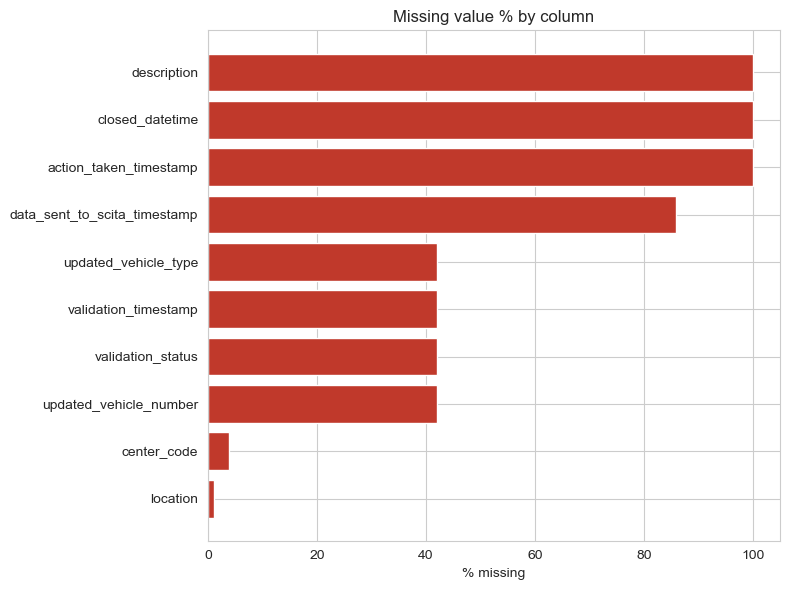

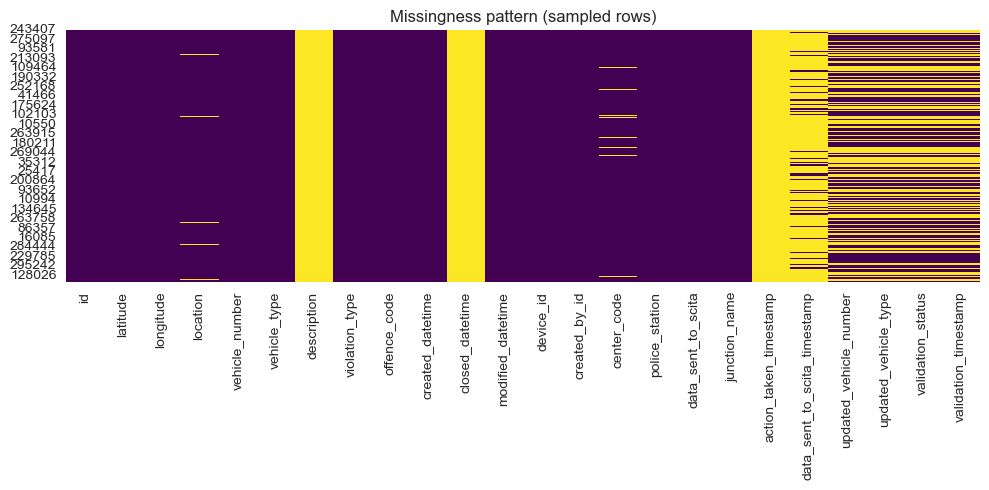


3. DATETIME PARSING
created_datetime                 non-null= 298,445  range=[2023-11-09 19:11:46+00:00 -> 2024-04-08 17:30:46+00:00]
closed_datetime                  all null
modified_datetime                non-null= 298,450  range=[2023-11-09 20:38:01.870979+00:00 -> 2024-04-19 21:46:25.637149+00:00]
data_sent_to_scita_timestamp     non-null=  42,161  range=[2024-03-22 10:54:47.389025+00:00 -> 2024-04-19 02:34:46.290473+00:00]
validation_timestamp             non-null= 173,030  range=[2023-11-14 19:07:37.925000+00:00 -> 2024-04-17 09:02:20.621000+00:00]

4. TEMPORAL TRENDS
Date range: 2023-11-09 -> 2024-04-08 (152 distinct days)
Avg violations/day: 1963.5  min=153  max=2858


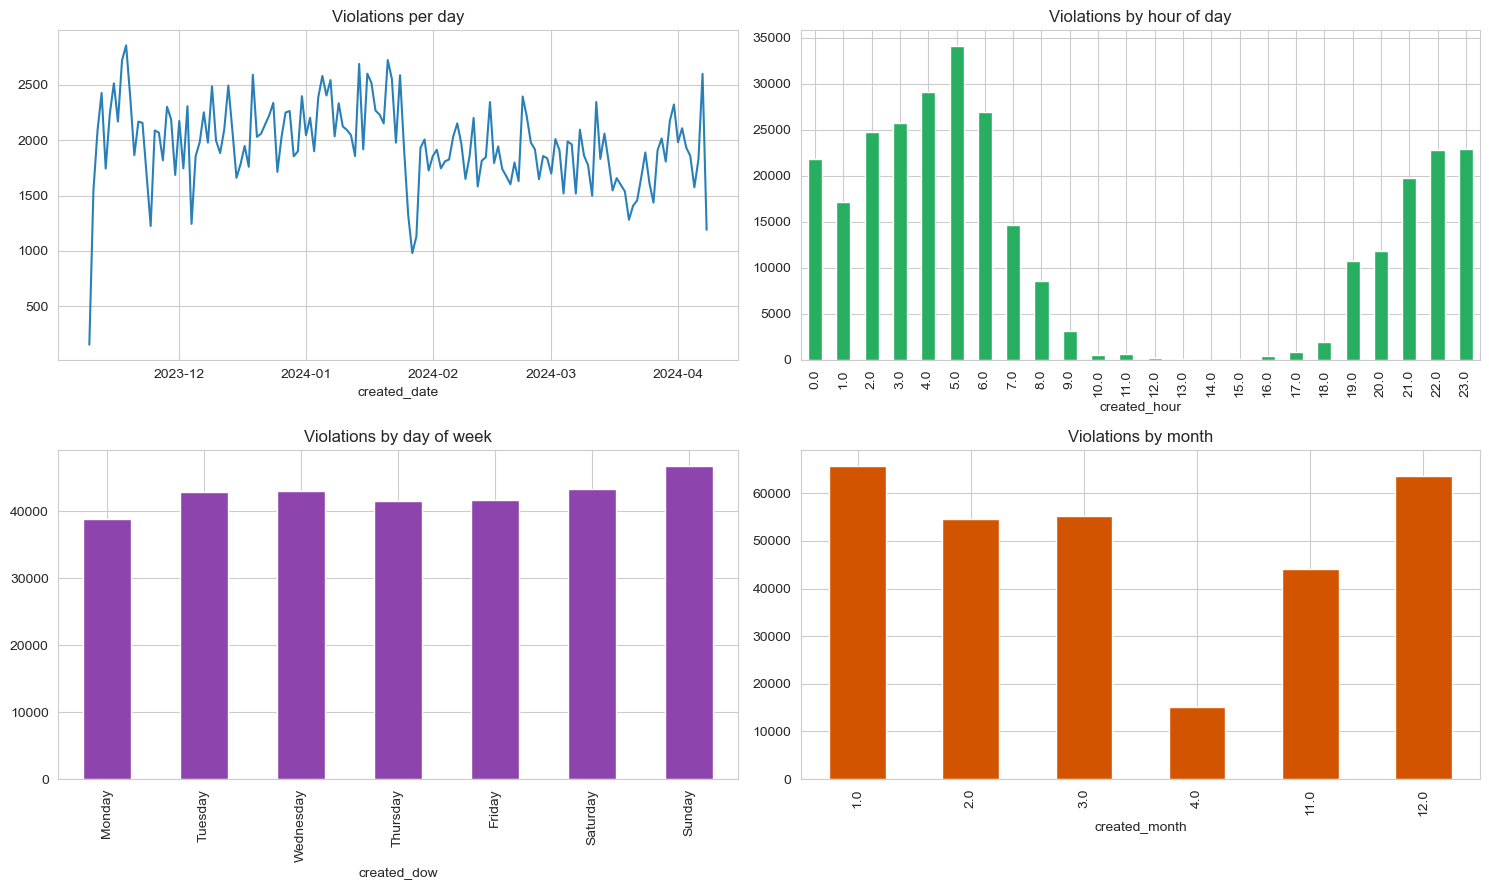


5. WORKFLOW / PROCESSING LATENCY

latency_created_to_modified_hr:
count   298,445.000
mean          8.515
std          41.053
min         -71.976
25%           0.082
50%           0.265
75%           1.186
max       2,686.383
Name: latency_created_to_modified_hr, dtype: float64

latency_created_to_scita_hr:
count   42,161.000
mean       468.665
std        241.295
min        360.756
25%        418.795
50%        428.420
75%        443.948
max      3,655.536
Name: latency_created_to_scita_hr, dtype: float64

latency_created_to_validation_hr:
count   173,030.000
mean         96.779
std         216.158
min         -14.665
25%          19.289
50%          31.042
75%          70.730
max       3,664.265
Name: latency_created_to_validation_hr, dtype: float64


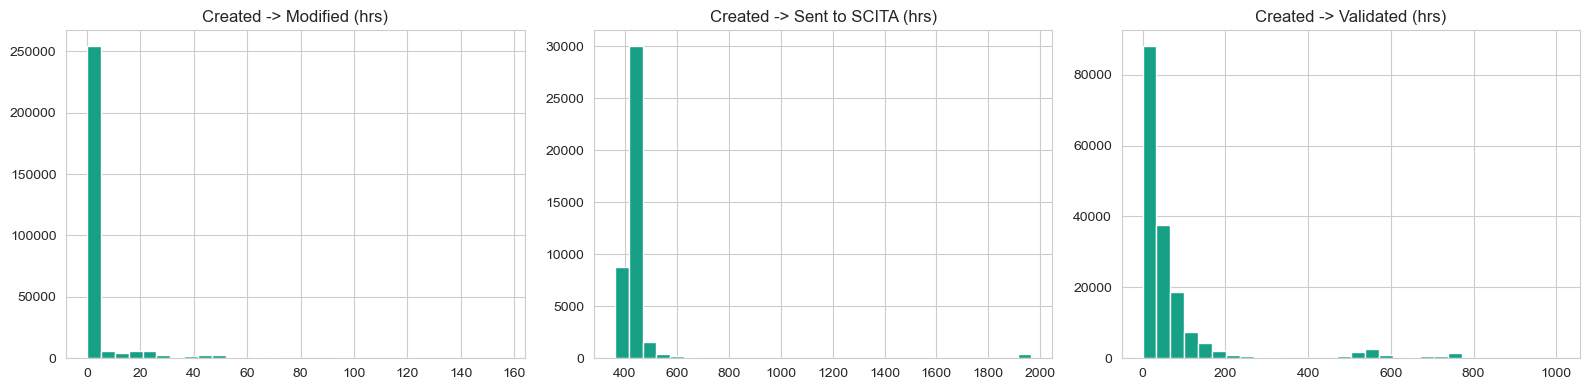


6. GEOSPATIAL ANALYSIS
         latitude   longitude
count 298,450.000 298,450.000
mean       12.981      77.601
std         0.050       0.051
min        12.803      77.443
25%        12.963      77.571
50%        12.977      77.584
75%        12.997      77.622
max        13.294      77.772

Coordinates outside expected city bounding box: 0 (0.00%)

Distance from city center (km): mean=6.17, max=36.44


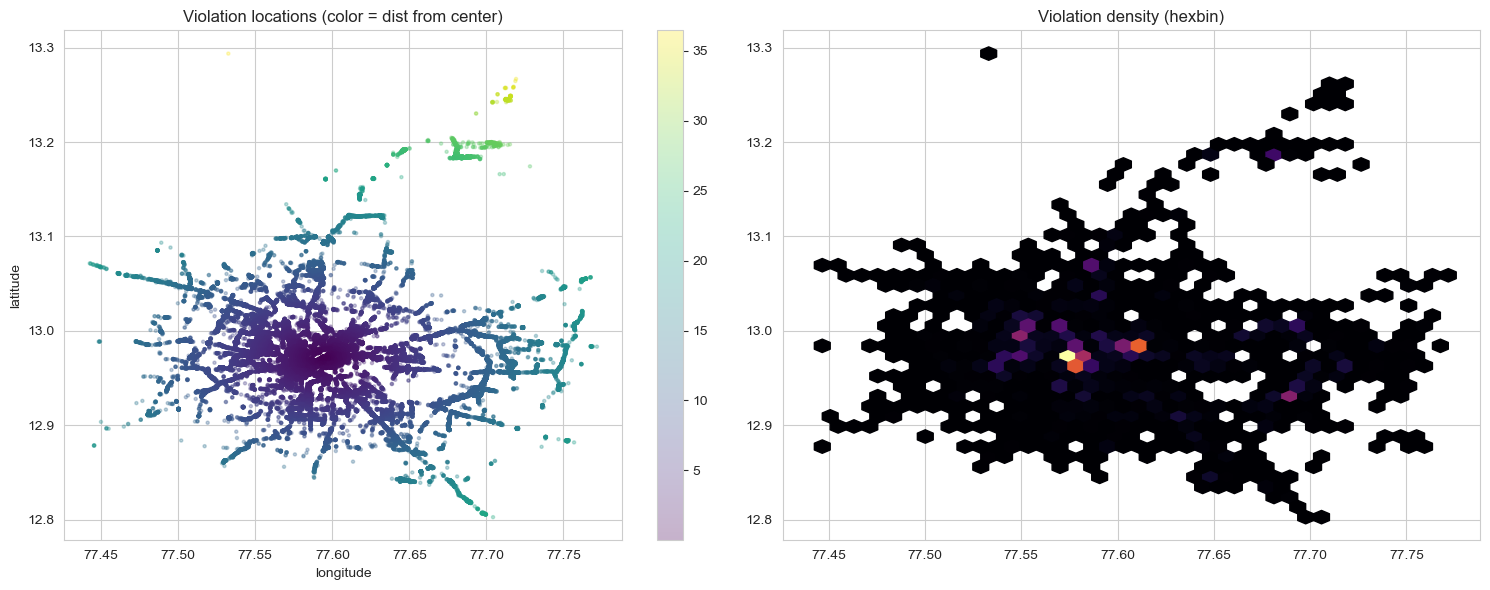


7. OUTLIER DETECTION (IQR method)
latitude               IQR=[12.912, 13.049]  outliers=35507 (11.90%)
longitude              IQR=[77.496, 77.697]  outliers=14995 (5.02%)
center_code            IQR=[-16.000, 56.000]  outliers=19488 (6.53%)
dist_from_center_km    IQR=[-7.827, 18.670]  outliers=7422 (2.49%)


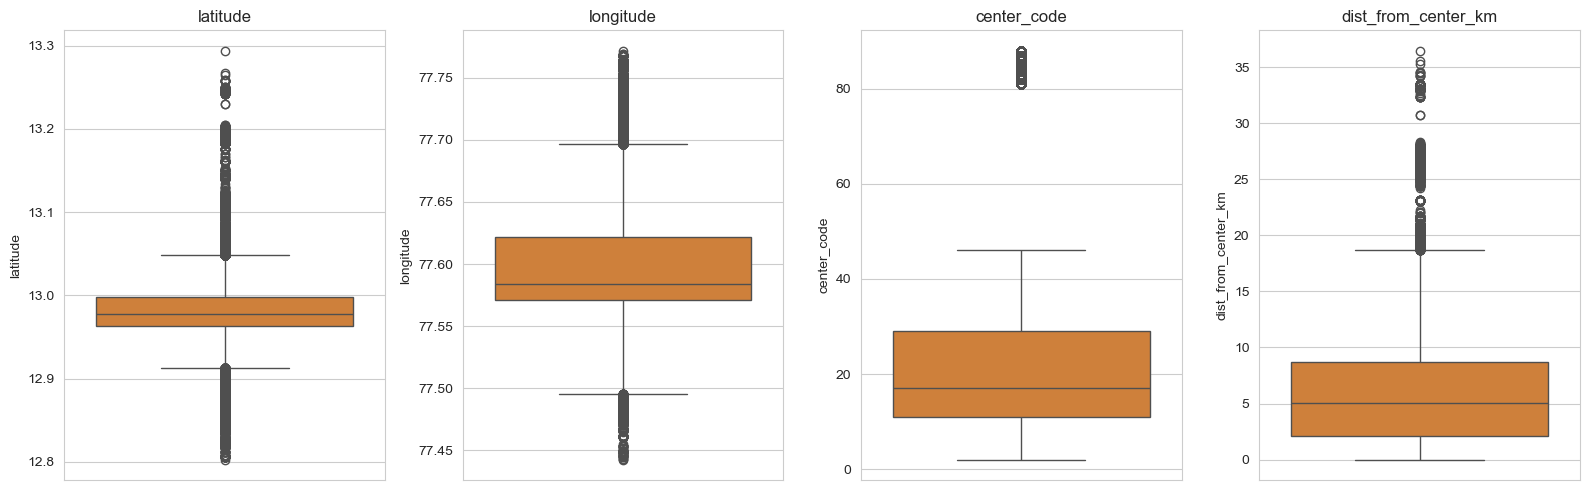


8. CATEGORICAL FEATURES

vehicle_type -> 22 unique values. Top 5:
vehicle_type
SCOOTER           94856
CAR               88870
MOTOR CYCLE       40811
PASSENGER AUTO    37813
MAXI-CAB          11372
Name: count, dtype: int64

police_station -> 54 unique values. Top 5:
police_station
Upparpet           34468
Shivajinagar       28044
Malleshwaram       22200
HAL Old Airport    20819
City Market        17646
Name: count, dtype: int64

junction_name -> 169 unique values. Top 5:
junction_name
No Junction                        147880
BTP051 - Safina Plaza Junction      15449
BTP082 - KR Market Junction         11538
BTP040 - Elite Junction             10718
BTP044 - Sagar Theatre Junction     10549
Name: count, dtype: int64

device_id -> 3070 unique values. Top 5:
device_id
FKDEV00021    4344
FKDEV00082    2268
FKDEV00077    2156
FKDEV00023    2145
FKDEV00075    2095
Name: count, dtype: int64

created_by_id -> 2666 unique values. Top 5:
created_by_id
FKUSR00021    4099
FKUSR00332    3467
F

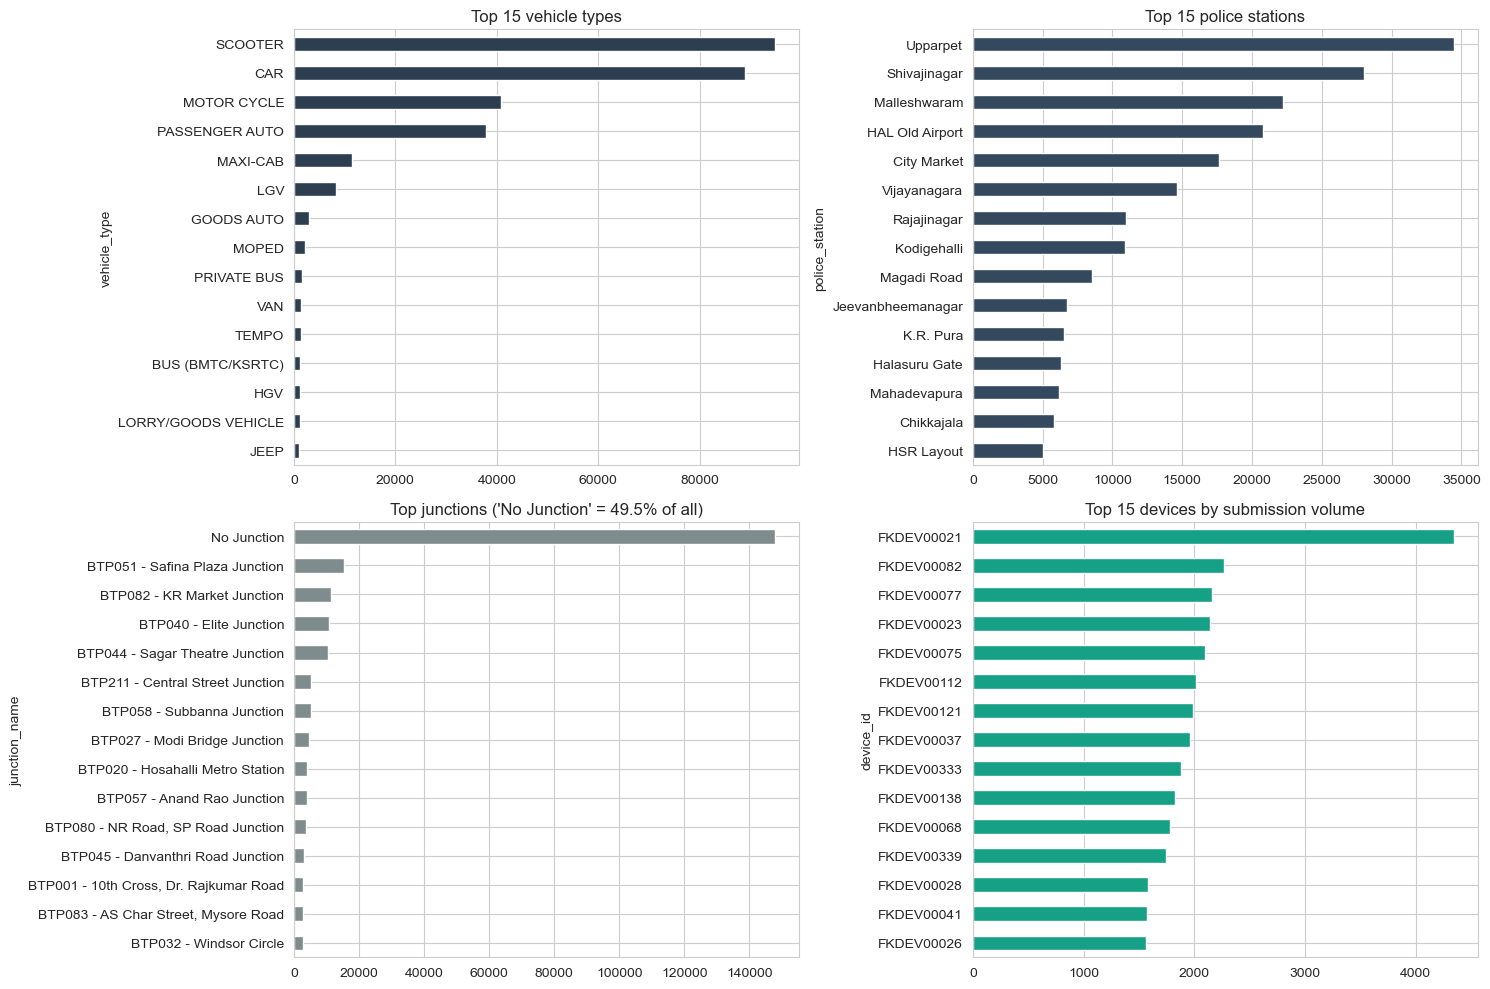


9. VIOLATION TYPE / OFFENCE CODE PARSING
Violations per record:
n_violations
1     258340
2      32951
3       5404
4       1192
5        294
6        180
7         51
8         21
9         15
11         1
12         1
Name: count, dtype: int64
Avg violations/record: 1.17

27 distinct violation types. Top 15:
violation_type_list
WRONG PARKING                                 164977
NO PARKING                                    139050
PARKING IN A MAIN ROAD                         23943
DEFECTIVE NUMBER PLATE                          7848
PARKING ON FOOTPATH                             3757
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         2403
DOUBLE PARKING                                  2037
PARKING NEAR ROAD CROSSING                      1687
REFUSE TO GO FOR HIRE                            887
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        525
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       486
USING BLACK FILM/OTHER MATERIALS                 248
PARKING OTHER THAN BUS STOP    

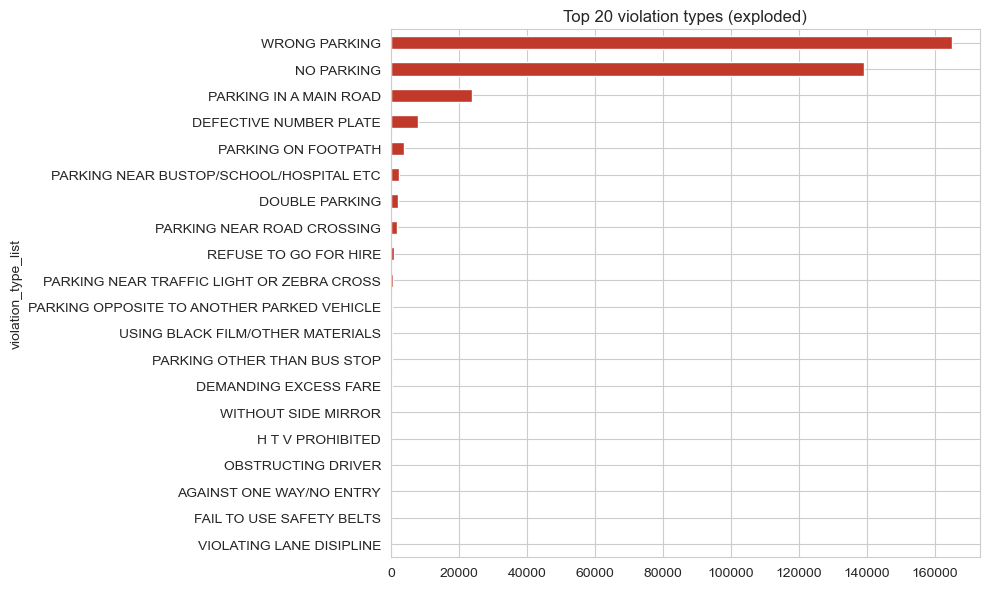


10. VALIDATION STATUS
validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
Name: count, dtype: int64

Unreviewed (null validation_status): 125254 (42.0%)

Approval/rejection rate by vehicle_type (row %):
validation_status    approved  created1  duplicate  processing  rejected
vehicle_type                                                            
BUS (BMTC/KSRTC)       34.600     6.200      0.000       0.100    59.100
CAR                    72.000     4.000      0.200       0.400    23.500
FACTORY BUS            59.800     4.700      0.000       0.000    35.400
GOODS AUTO             65.300     3.200      0.100       0.300    31.100
HGV                    62.000     5.000      0.000       0.300    32.700
JEEP                   70.500     2.600      0.400       0.200    26.400
LGV                    64.300     4.700      0.000       0.200    30.800
LORRY/GOODS VEHICLE    62.800     3.800      0.

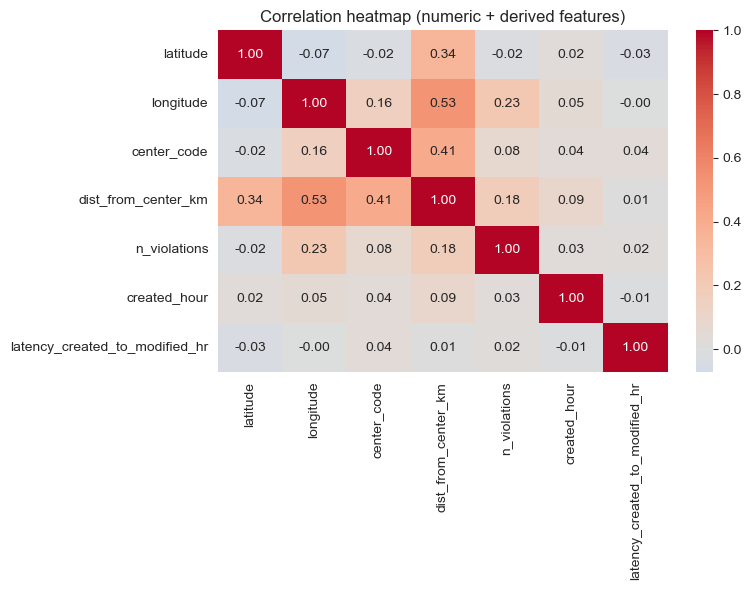


14. KEY EDA TAKEAWAYS

- 298,450 rows, 24 original columns (38 after EDA feature derivation).
- Fully-empty columns to drop: ['description', 'closed_datetime', 'action_taken_timestamp']
- ~42.0% of records have no validation_status yet (pending review).
- 58.0% of records were touched by a human reviewer (updated_* populated).
- Avg 1.17 violation tags per record; most common: WRONG PARKING.
- 49.5% of violations are NOT at a named junction ("No Junction").
- 0 rows have coordinates outside the expected city bounding box.
- 35587 vehicle numbers appear more than once (repeat offenders / re-detections).

EDA complete. Proceed to feature engineering.


In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import json, ast
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "data/dataset.csv"   # <-- set this

def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

# ============================================================================
# 1. LOAD & QUICK RECAP
# ============================================================================
section("1. LOAD DATA")
df = pd.read_csv(DATA_PATH, na_values=["NULL", "null", "", "NaN", "None"], keep_default_na=True)
N_ORIGINAL_COLS = df.shape[1]
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Duplicate full rows: {df.duplicated().sum()}")
print(f"Duplicate ids: {df['id'].duplicated().sum()}")

# ============================================================================
# 2. MISSING VALUE DEEP-DIVE
# ============================================================================
section("2. MISSING VALUES")
miss = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2)
}).sort_values("missing_pct", ascending=False)
print(miss[miss.missing_count > 0])

fully_null_cols = miss[miss.missing_pct == 100].index.tolist()
print(f"\n100% null columns (drop candidates): {fully_null_cols}")

fig, ax = plt.subplots(figsize=(8, 6))
miss_nonzero = miss[miss.missing_pct > 0].sort_values("missing_pct")
ax.barh(miss_nonzero.index, miss_nonzero.missing_pct, color="#c0392b")
ax.set_xlabel("% missing")
ax.set_title("Missing value % by column")
plt.tight_layout()
plt.show()

# Missingness pattern heatmap (sampled for large data)
sample_for_heatmap = df.sample(min(2000, len(df)), random_state=42) if len(df) > 2000 else df
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(sample_for_heatmap.isna(), cbar=False, cmap="viridis", ax=ax)
ax.set_title("Missingness pattern (sampled rows)")
plt.tight_layout()
plt.show()

# ============================================================================
# 3. DATETIME PARSING + DERIVED TEMPORAL FEATURES
# ============================================================================
section("3. DATETIME PARSING")
datetime_cols = ["created_datetime", "closed_datetime", "modified_datetime",
                  "data_sent_to_scita_timestamp", "validation_timestamp"]
for c in datetime_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], utc=True, errors="coerce")
        if df[c].notna().sum() > 0:
            print(f"{c:32s} non-null={df[c].notna().sum():>8,}  "
                  f"range=[{df[c].min()} -> {df[c].max()}]")
        else:
            print(f"{c:32s} all null")

df["created_date"] = df["created_datetime"].dt.date
df["created_year"] = df["created_datetime"].dt.year
df["created_month"] = df["created_datetime"].dt.month
df["created_hour"] = df["created_datetime"].dt.hour
df["created_dow"] = df["created_datetime"].dt.day_name()
df["created_dow_num"] = df["created_datetime"].dt.dayofweek
df["created_is_weekend"] = df["created_dow_num"].isin([5, 6])

# Boolean normalization (in case read as string)
if df["data_sent_to_scita"].dtype != bool:
    df["data_sent_to_scita"] = df["data_sent_to_scita"].astype(str).str.upper().map(
        {"TRUE": True, "FALSE": False}
    )

# ============================================================================
# 4. TEMPORAL TREND ANALYSIS
# ============================================================================
section("4. TEMPORAL TRENDS")
daily_counts = df.groupby("created_date").size()
print(f"Date range: {daily_counts.index.min()} -> {daily_counts.index.max()} "
      f"({len(daily_counts)} distinct days)")
print(f"Avg violations/day: {daily_counts.mean():.1f}  "
      f"min={daily_counts.min()}  max={daily_counts.max()}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
daily_counts.plot(ax=axes[0, 0], title="Violations per day", color="#2980b9")
df["created_hour"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 1], title="Violations by hour of day", color="#27ae60")
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["created_dow"].value_counts().reindex(dow_order).plot(
    kind="bar", ax=axes[1, 0], title="Violations by day of week", color="#8e44ad")
df.groupby("created_month").size().plot(
    kind="bar", ax=axes[1, 1], title="Violations by month", color="#d35400")
plt.tight_layout()
plt.show()

# ============================================================================
# 5. WORKFLOW LATENCY ANALYSIS (created -> modified -> sent -> validated)
# ============================================================================
section("5. WORKFLOW / PROCESSING LATENCY")
df["latency_created_to_modified_hr"] = (
    df["modified_datetime"] - df["created_datetime"]
).dt.total_seconds() / 3600
df["latency_created_to_scita_hr"] = (
    df["data_sent_to_scita_timestamp"] - df["created_datetime"]
).dt.total_seconds() / 3600
df["latency_created_to_validation_hr"] = (
    df["validation_timestamp"] - df["created_datetime"]
).dt.total_seconds() / 3600

for col in ["latency_created_to_modified_hr", "latency_created_to_scita_hr",
            "latency_created_to_validation_hr"]:
    valid = df[col].dropna()
    if len(valid) > 0:
        print(f"\n{col}:")
        print(valid.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(
    axes,
    ["latency_created_to_modified_hr", "latency_created_to_scita_hr", "latency_created_to_validation_hr"],
    ["Created -> Modified (hrs)", "Created -> Sent to SCITA (hrs)", "Created -> Validated (hrs)"]
):
    data = df[col].dropna()
    if len(data) > 1:
        data = data[(data >= 0) & (data < data.quantile(0.99))]
    if len(data) > 0:
        ax.hist(data, bins=30, color="#16a085")
    ax.set_title(title)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. GEOSPATIAL ANALYSIS
# ============================================================================
section("6. GEOSPATIAL ANALYSIS")
print(df[["latitude", "longitude"]].describe())

# Bengaluru approximate bounding box -- adjust if source city differs
LAT_MIN, LAT_MAX = 12.7, 13.3
LON_MIN, LON_MAX = 77.3, 77.9
out_of_bounds = df[
    ~df["latitude"].between(LAT_MIN, LAT_MAX) | ~df["longitude"].between(LON_MIN, LON_MAX)
]
print(f"\nCoordinates outside expected city bounding box: {len(out_of_bounds)} "
      f"({len(out_of_bounds) / len(df) * 100:.2f}%)")

# city-center distance (haversine) as an engineered sanity feature
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

CITY_CENTER = (12.9716, 77.5946)  # MG Road, Bengaluru
df["dist_from_center_km"] = haversine_km(df["latitude"], df["longitude"], *CITY_CENTER)
print(f"\nDistance from city center (km): "
      f"mean={df['dist_from_center_km'].mean():.2f}, "
      f"max={df['dist_from_center_km'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc = axes[0].scatter(df["longitude"], df["latitude"], s=5, alpha=0.3, c=df["dist_from_center_km"], cmap="viridis")
axes[0].set_title("Violation locations (color = dist from center)")
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")
plt.colorbar(sc, ax=axes[0])
axes[1].hexbin(df["longitude"], df["latitude"], gridsize=40, cmap="inferno", mincnt=1)
axes[1].set_title("Violation density (hexbin)")
plt.tight_layout()
plt.show()

# ============================================================================
# 7. OUTLIER DETECTION (numeric)
# ============================================================================
section("7. OUTLIER DETECTION (IQR method)")
num_cols = ["latitude", "longitude", "center_code", "dist_from_center_km"]
for c in num_cols:
    if c in df.columns and df[c].notna().sum() > 0:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        print(f"{c:22s} IQR=[{lo:.3f}, {hi:.3f}]  outliers={n_out} ({n_out/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#e67e22")
    ax.set_title(c)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. CATEGORICAL DEEP-DIVE
# ============================================================================
section("8. CATEGORICAL FEATURES")
cat_cols = ["vehicle_type", "police_station", "junction_name", "device_id", "created_by_id"]
for c in cat_cols:
    if c in df.columns:
        n_unique = df[c].nunique()
        top = df[c].value_counts().head(5)
        print(f"\n{c} -> {n_unique} unique values. Top 5:")
        print(top)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df["vehicle_type"].value_counts().head(15).plot(kind="barh", ax=axes[0,0], color="#2c3e50")
axes[0,0].set_title("Top 15 vehicle types"); axes[0,0].invert_yaxis()
df["police_station"].value_counts().head(15).plot(kind="barh", ax=axes[0,1], color="#34495e")
axes[0,1].set_title("Top 15 police stations"); axes[0,1].invert_yaxis()
junction_share = (df["junction_name"] == "No Junction").mean() * 100
df["junction_name"].value_counts().head(15).plot(kind="barh", ax=axes[1,0], color="#7f8c8d")
axes[1,0].set_title(f"Top junctions ('No Junction' = {junction_share:.1f}% of all)")
axes[1,0].invert_yaxis()
df["device_id"].value_counts().head(15).plot(kind="barh", ax=axes[1,1], color="#16a085")
axes[1,1].set_title("Top 15 devices by submission volume"); axes[1,1].invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 9. LIST-LIKE COLUMNS: violation_type / offence_code
# ============================================================================
section("9. VIOLATION TYPE / OFFENCE CODE PARSING")

def safe_list_parse(x):
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []

df["violation_type_list"] = df["violation_type"].apply(safe_list_parse)
df["offence_code_list"] = df["offence_code"].apply(safe_list_parse)
df["n_violations"] = df["violation_type_list"].apply(len)

print("Violations per record:")
print(df["n_violations"].value_counts().sort_index())
print(f"Avg violations/record: {df['n_violations'].mean():.2f}")

exploded = df.explode("violation_type_list")["violation_type_list"].dropna()
top_violations = exploded.value_counts()
print(f"\n{len(top_violations)} distinct violation types. Top 15:")
print(top_violations.head(15))

# co-occurrence: which violations appear together in multi-violation records
multi = df[df["n_violations"] > 1]["violation_type_list"]
from itertools import combinations
from collections import Counter
pair_counts = Counter()
for lst in multi:
    for combo in combinations(sorted(set(lst)), 2):
        pair_counts[combo] += 1
print("\nTop co-occurring violation pairs:")
for pair, cnt in pair_counts.most_common(10):
    print(f"  {pair}: {cnt}")

fig, ax = plt.subplots(figsize=(10, 6))
top_violations.head(20).plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Top 20 violation types (exploded)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 10. VALIDATION STATUS ANALYSIS
# ============================================================================
section("10. VALIDATION STATUS")
print(df["validation_status"].value_counts(dropna=False))
print(f"\nUnreviewed (null validation_status): "
      f"{df['validation_status'].isna().sum()} ({df['validation_status'].isna().mean()*100:.1f}%)")

if df["validation_status"].notna().sum() > 0:
    ct = pd.crosstab(df["vehicle_type"], df["validation_status"], normalize="index").mul(100).round(1)
    print("\nApproval/rejection rate by vehicle_type (row %):")
    print(ct)

    ct2 = pd.crosstab(df["data_sent_to_scita"], df["validation_status"])
    print("\nvalidation_status vs data_sent_to_scita:")
    print(ct2)

# ============================================================================
# 11. DATA CORRECTION / OCR-ACCURACY ANALYSIS
# ============================================================================
section("11. VEHICLE NUMBER/TYPE CORRECTION ANALYSIS")
has_update = df["updated_vehicle_number"].notna()
print(f"Records with a human-reviewed update: {has_update.sum()} / {len(df)} "
      f"({has_update.mean()*100:.1f}%)")
if has_update.sum() > 0:
    vn_changed = (df.loc[has_update, "vehicle_number"] != df.loc[has_update, "updated_vehicle_number"]).mean()
    vt_changed = (df.loc[has_update, "vehicle_type"] != df.loc[has_update, "updated_vehicle_type"]).mean()
    print(f"Vehicle NUMBER corrected on review: {vn_changed*100:.2f}%")
    print(f"Vehicle TYPE corrected on review:   {vt_changed*100:.2f}%")

# ============================================================================
# 12. DATA INTEGRITY / REPEAT OFFENDER CHECKS
# ============================================================================
section("12. DATA INTEGRITY & REPEAT OFFENDERS")
vn_counts = df["vehicle_number"].value_counts()
repeat_offenders = vn_counts[vn_counts > 1]
print(f"Vehicles appearing more than once: {len(repeat_offenders)} "
      f"(max repeats: {vn_counts.max() if len(vn_counts) else 0})")
print(f"id column unique: {df['id'].is_unique}")
print(f"Rows missing police_station/junction_name/created_by_id "
      f"(likely same corrupt rows): {df[['police_station','junction_name','created_by_id']].isna().any(axis=1).sum()}")

# ============================================================================
# 13. CORRELATION (numeric + derived)
# ============================================================================
section("13. CORRELATION MATRIX")
corr_cols = ["latitude", "longitude", "center_code", "dist_from_center_km",
             "n_violations", "created_hour", "latency_created_to_modified_hr"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation heatmap (numeric + derived features)")
plt.tight_layout()
plt.show()

# ============================================================================
# 14. SUMMARY
# ============================================================================
section("14. KEY EDA TAKEAWAYS")
print(f"""
- {df.shape[0]:,} rows, {N_ORIGINAL_COLS} original columns ({df.shape[1]} after EDA feature derivation).
- Fully-empty columns to drop: {fully_null_cols}
- ~{df['validation_status'].isna().mean()*100:.1f}% of records have no validation_status yet (pending review).
- {has_update.mean()*100:.1f}% of records were touched by a human reviewer (updated_* populated).
- Avg {df['n_violations'].mean():.2f} violation tags per record; most common: {top_violations.index[0] if len(top_violations) else 'N/A'}.
- {junction_share:.1f}% of violations are NOT at a named junction ("No Junction").
- {len(out_of_bounds)} rows have coordinates outside the expected city bounding box.
- {len(repeat_offenders)} vehicle numbers appear more than once (repeat offenders / re-detections).
""")
print("EDA complete. Proceed to feature engineering.")

In [6]:
df['location'].value_counts()

location
Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)                                                                                              4090
Kamaraj Road, Sri Nagamma Devi Circle, Sivanchetti Gardens, Bengaluru, Karnataka. Pin-560042 (India)                                                                     3999
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)                                                  3785
MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)                                                                                        3027
Dispensary Road, Tasker Town, Shivaji Nagar, Bengaluru, Karnataka. Pin-560001 (India)                                                                                    2670
                                                                                                                         

In [23]:
import re
import pandas as pd
import ast
from sklearn.preprocessing import LabelEncoder

# ============================================================
# NOTE ON THE FIX APPLIED IN THIS FILE
# ------------------------------------------------------------
# The original script crashed with:
#   ValueError: Cannot convert non-finite values (NA or inf) to integer
# This happens whenever `.astype(int)` is called on a column that
# contains NaN/NaT (e.g. a regex that didn't match, or a timestamp
# that failed to parse). Plain numpy `int` has no way to represent
# a missing value, so pandas refuses the cast.
#
# Fix: wherever a NaN/NaT could be present, we cast to the
# *nullable* integer dtype `'Int64'` (capital I) instead of the
# numpy `int`. This keeps missing rows as `<NA>` instead of raising.
# No other logic was changed.
# ============================================================

# lets do by column by column

# create new csv files and store the data in them for further analysis

new_df = pd.DataFrame()
# keep id as it is
new_df['id'] = df['id']
# keep latitude and longitude as it is
new_df['latitude'] = df['latitude']
new_df['longitude'] = df['longitude']


def extract_area(location):
    if pd.isna(location):
        return None

    parts = [x.strip() for x in str(location).split(',')]

    for i, part in enumerate(parts):
        if 'bengaluru' in part.lower() or 'bangalore' in part.lower():
            if i > 0:
                return parts[i-1]

    return None


def extract_pincode(location):
    if pd.isna(location):
        return None

    match = re.search(r'(\d{6})', str(location))
    return match.group(1) if match else None


new_df['area'] = df['location'].apply(extract_area)
new_df['pincode'] = df['location'].apply(extract_pincode)

# vehicle number
# FKN00GL0000--> 0
# FIX: some vehicle_number values may not end in digits, in which case
# str.extract() returns NaN for that row. Use the nullable 'Int64'
# dtype so those rows become <NA> instead of crashing the cast.
df['vehicle_num_id'] = df['vehicle_number'].str.extract(r'(\d+)$').astype('Int64')

# vehicle_type: 22 unique values
le = LabelEncoder()

new_df['vehicle_type_encoded'] = le.fit_transform(df['vehicle_type'])

# Mapping table
mapping = pd.DataFrame({
    'Encoded_Value': range(len(le.classes_)),
    'Vehicle_Type': le.classes_
})

print(mapping)

# violation_type: 27 unique values

# ============================================================
# Create a mapping:
# "NO PARKING" -> "NO PARKING--113"
# "WRONG PARKING" -> "WRONG PARKING--112"
# ============================================================

col_map = {
    row['violation_type']: f"{row['violation_type']}--{row['offence_code']}"
    for _, row in mapping_df.iterrows()
}

# ============================================================
# Add all OHE columns to new_df and initialize with 0
# ============================================================

for col_name in col_map.values():
    new_df[col_name] = 0

# ============================================================
# Populate OHE columns
#
# Example:
# df['violation_type'] =
# '["WRONG PARKING","PARKING IN A MAIN ROAD"]'
#
# Result:
# new_df['WRONG PARKING--112'] = 1
# new_df['PARKING IN A MAIN ROAD--107'] = 1
# ============================================================

for idx, violation_list in df['violation_type'].items():

    # Skip missing values
    if pd.isna(violation_list):
        continue

    # Convert string representation of list to Python list
    # '["NO PARKING"]' -> ['NO PARKING']
    violations = ast.literal_eval(violation_list)

    # Set corresponding OHE columns to 1
    for violation in violations:

        if violation in col_map:
            column_name = col_map[violation]
            new_df.loc[idx, column_name] = 1

# ============================================================
# Verification
# ============================================================

print(f"Total OHE columns created: {len(col_map)}")

# Display first few rows of OHE columns
print(new_df[list(col_map.values())].head())

# Count occurrences of each violation type
print("\nViolation Counts:")
print(
    new_df[list(col_map.values())]
    .sum()
    .sort_values(ascending=False)
)

# created_date_time
# Convert to datetime
dt = pd.to_datetime(df['created_datetime'])

# Extract components and store in new_df
new_df['created_year'] = dt.dt.year
new_df['created_month'] = dt.dt.month
new_df['created_day'] = dt.dt.day

new_df['created_hour'] = dt.dt.hour
new_df['created_minute'] = dt.dt.minute
new_df['created_second'] = dt.dt.second

# skip closed_datetime as it is 100% missing

# modified_datetime
# Convert modified_datetime to datetime format
dt = pd.to_datetime(df['modified_datetime'])

# Extract components into new_df
new_df['modified_year'] = dt.dt.year
new_df['modified_month'] = dt.dt.month
new_df['modified_day'] = dt.dt.day

new_df['modified_hour'] = dt.dt.hour
new_df['modified_minute'] = dt.dt.minute

# Convert seconds (including fractional seconds) to integer seconds
# FIX: if any modified_datetime values failed to parse (NaT), dt.dt.second
# is NaN for those rows -> use nullable 'Int64' instead of int.
new_df['modified_second'] = dt.dt.second.astype('Int64')

# device_id
# FKDEV00000 -> 0
# FKDEV00001 -> 1
# FKDEV00008 -> 8
# FIX: nullable 'Int64' guards against any device_id that doesn't match
# the trailing-digits pattern.
new_df['device_id_int'] = (
    df['device_id']
    .str.extract(r'(\d+)$')[0]
    .astype('Int64')
)

# FKUSR00000 -> 0
# FKUSR00001 -> 1
# FKUSR00008 -> 8
# FIX: same reasoning as device_id_int above.
new_df['created_by_id_int'] = (
    df['created_by_id']
    .str.extract(r'(\d+)$')[0]
    .astype('Int64')
)

# center code
new_df['center_code'] = df['center_code']

# police station and data_sent_to_scita
new_df['police_station'] = df['police_station']
new_df['data_sent_to_scita'] = df['data_sent_to_scita']

# junction_name
new_df['junction_name'] = df['junction_name']

# data_sent_to_scita_timestamp
dt = pd.to_datetime(df['data_sent_to_scita_timestamp'])

# Extract components into new_df
new_df['data_sent_to_scita_modified_year'] = dt.dt.year
new_df['data_sent_to_scita_modified_month'] = dt.dt.month
new_df['data_sent_to_scita_modified_day'] = dt.dt.day

new_df['data_sent_to_scita_modified_hour'] = dt.dt.hour
new_df['data_sent_to_scita_modified_minute'] = dt.dt.minute

# Convert seconds (including fractional seconds) to integer seconds
# FIX: data_sent_to_scita_timestamp is likely to have many missing/unparseable
# values, producing NaT -> NaN seconds. Use nullable 'Int64' to avoid the crash.
new_df['data_sent_to_scita_modified_second'] = dt.dt.second.astype('Int64')

# updated_vehicle_number and updated_vehicle_type
# FIX: same NaN-from-regex issue as vehicle_num_id above.
df['updated_vehicle_number'] = df['updated_vehicle_number'].str.extract(r'(\d+)$').astype('Int64')

# vehicle_type: 22 unique values
le = LabelEncoder()

new_df['updated_vehicle_type_encoded'] = le.fit_transform(df['updated_vehicle_type'])  # df['vehicle_type'])

# Mapping table
mapping = pd.DataFrame({
    'Encoded_Value': range(len(le.classes_)),
    'Vehicle_Type': le.classes_
})

print(mapping)

# validation_status
new_df['validation_status'] = df['validation_status']

# validation_timestamp
dt = pd.to_datetime(df['validation_timestamp'])

# Extract components into new_df
new_df['validation_year'] = dt.dt.year
new_df['validation_month'] = dt.dt.month
new_df['validation_day'] = dt.dt.day

new_df['validation_hour'] = dt.dt.hour
new_df['validation_minute'] = dt.dt.minute

# Convert seconds (including fractional seconds) to integer seconds
# FIX: same NaT-from-failed-parse issue -> nullable 'Int64' instead of int.
new_df['validation_second'] = dt.dt.second.astype('Int64')

# save new_df to csv
new_df.to_csv("data/processed_dataset.csv", index=False)

    Encoded_Value         Vehicle_Type
0               0     BUS (BMTC/KSRTC)
1               1                  CAR
2               2          FACTORY BUS
3               3           GOODS AUTO
4               4                  HGV
5               5                 JEEP
6               6                  LGV
7               7  LORRY/GOODS VEHICLE
8               8             MAXI-CAB
9               9           MINI LORRY
10             10                MOPED
11             11          MOTOR CYCLE
12             12               OTHERS
13             13       PASSENGER AUTO
14             14          PRIVATE BUS
15             15       SCHOOL VEHICLE
16             16              SCOOTER
17             17               TANKER
18             18                TEMPO
19             19          TOURIST BUS
20             20              TRACTOR
21             21                  VAN
Total OHE columns created: 27
   PARKING NEAR ROAD CROSSING--104  PARKING ON FOOTPATH--105  PARKING NEA

In [ ]:
import pandas as pd
import ast

# Create set to store unique pairs
unique_pairs = set()

for _, row in df[['violation_type', 'offence_code']].dropna().iterrows():

    violations = ast.literal_eval(row['violation_type'])
    codes = ast.literal_eval(row['offence_code'])

    for v, c in zip(violations, codes):
        unique_pairs.add((v, c))

# Convert to DataFrame
mapping_df = pd.DataFrame(
    list(unique_pairs),
    columns=['violation_type', 'offence_code']
).sort_values('offence_code')

print(mapping_df)


                                violation_type  offence_code
20                  PARKING NEAR ROAD CROSSING           104
5                          PARKING ON FOOTPATH           105
24   PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS           106
19                      PARKING IN A MAIN ROAD           107
4   PARKING OPPOSITE TO ANOTHER PARKED VEHICLE           108
11                              DOUBLE PARKING           109
25                    FAIL TO USE SAFETY BELTS           110
15     PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC           111
7                                WRONG PARKING           112
16                                  NO PARKING           113
21                      JUMPING TRAFFIC SIGNAL           115
12                      DEFECTIVE NUMBER PLATE           116
1                    CARRYING LENGHTY MATERIAL           123
6                        REFUSE TO GO FOR HIRE           124
9                        DEMANDING EXCESS FARE           125
17                    VI

27


In [24]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("data/processed_dataset.csv")

print("="*50)
print("1. Dataset Shape")
print("="*50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "="*50)
print("2. Column Names")
print("="*50)
print(df.columns.tolist())

print("\n" + "="*50)
print("3. Data Types")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("4. First 5 Rows")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("5. Last 5 Rows")
print("="*50)
print(df.tail())

print("\n" + "="*50)
print("6. Missing Values")
print("="*50)
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100, 2)
})
print(missing.sort_values('Missing Count', ascending=False))

print("\n" + "="*50)
print("7. Duplicate Rows")
print("="*50)
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\n" + "="*50)
print("8. Numerical Summary")
print("="*50)
print(df.describe().T)

print("\n" + "="*50)
print("9. Categorical Summary")
print("="*50)
print(df.describe(include='object').T)

print("\n" + "="*50)
print("10. Unique Values")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n" + "="*50)
print("11. Memory Usage")
print("="*50)
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

print("\n" + "="*50)
print("12. Potential Outliers (IQR Method)")
print("="*50)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

1. Dataset Shape
Rows: 298450
Columns: 65

2. Column Names
['id', 'latitude', 'longitude', 'area', 'pincode', 'vehicle_type_encoded', 'PARKING NEAR ROAD CROSSING--104', 'PARKING ON FOOTPATH--105', 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS--106', 'PARKING IN A MAIN ROAD--107', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE--108', 'DOUBLE PARKING--109', 'FAIL TO USE SAFETY BELTS--110', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC--111', 'WRONG PARKING--112', 'NO PARKING--113', 'JUMPING TRAFFIC SIGNAL--115', 'DEFECTIVE NUMBER PLATE--116', 'CARRYING LENGHTY MATERIAL--123', 'REFUSE TO GO FOR HIRE--124', 'DEMANDING EXCESS FARE--125', 'VIOLATING LANE DISIPLINE--130', 'USING BLACK FILM/OTHER MATERIALS--133', 'U TURN PROHIBITED--134', 'AGAINST ONE WAY/NO ENTRY--135', 'OBSTRUCTING DRIVER--136', 'PARKING OTHER THAN BUS STOP--139', 'RIDER NOT WEARING HELMET--140', 'WITHOUT SIDE MIRROR--144', 'STOPING ON WHITE/STOP LINE--146', 'H T V PROHIBITED--147', '2W/3W - USING MOBILE PHONE--237', 'OTHER - USING MOB

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13

DATA_PATH = "data/processed_dataset.csv"   # change to your full file path
OUT_DIR = "eda_output"
os.makedirs(OUT_DIR, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{name}.png", dpi=150)
    plt.close()

# ---------------- LOAD ----------------
df = pd.read_csv(DATA_PATH)

violation_cols = [c for c in df.columns if "--" in c]
id_like = ["device_id_int", "created_by_id_int", "center_code"]
geo_cols = ["latitude", "longitude"]

df["created_date"] = pd.to_datetime(
    dict(year=df["created_year"], month=df["created_month"], day=df["created_day"]),
    errors="coerce"
)
df["created_dow"] = df["created_date"].dt.day_name()
df["created_weekofyear"] = df["created_date"].dt.isocalendar().week

# ---------------- 1. SHAPE / DTYPES ----------------
print(df.shape)
print(df.dtypes)
print(df.describe(include="all").T)

# ---------------- 2. MISSING VALUES ----------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing"] > 0]

plt.figure(figsize=(10, max(6, len(missing_df) * 0.3)))
sns.barplot(x=missing_df["pct"], y=missing_df.index, palette="rocket")
plt.xlabel("% Missing")
plt.title("Missing Values by Column")
save("01_missing_values_bar")

plt.figure(figsize=(14, 8))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Value Pattern")
save("02_missing_value_heatmap")

# ---------------- 3. NUMERIC DISTRIBUTIONS ----------------
num_cols = ["latitude", "longitude", "pincode", "vehicle_type_encoded",
            "updated_vehicle_type_encoded", "device_id_int", "created_by_id_int", "center_code"]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=True, color="steelblue")
    plt.title(f"Distribution: {col}")
    save(f"03_hist_{col}")

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="orange")
    ax.set_title(col)
save("04_boxplots_numeric")

# ---------------- 4. VIOLATION FREQUENCIES ----------------
violation_sums = df[violation_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=violation_sums.values, y=violation_sums.index, palette="mako")
plt.xlabel("Count")
plt.title("Total Violation Counts by Type")
save("05_violation_counts_bar")

plt.figure(figsize=(10, 10))
violation_pct = violation_sums / len(df) * 100
sns.barplot(x=violation_pct.values, y=violation_pct.index, palette="flare")
plt.xlabel("% of Rows Flagged")
plt.title("Violation Prevalence (%)")
save("06_violation_prevalence_pct")

top10 = violation_sums.head(10)
plt.figure(figsize=(8, 8))
plt.pie(top10.values, labels=top10.index, autopct="%1.1f%%", textprops={"fontsize": 8})
plt.title("Top 10 Violations Share")
save("07_top10_violations_pie")

# ---------------- 5. VIOLATION CO-OCCURRENCE ----------------
co_matrix = df[violation_cols].T.dot(df[violation_cols])
np.fill_diagonal(co_matrix.values, 0)
plt.figure(figsize=(16, 14))
sns.heatmap(co_matrix, cmap="YlOrRd", annot=False)
plt.title("Violation Co-occurrence Matrix")
save("08_violation_cooccurrence_heatmap")

plt.figure(figsize=(16, 14))
corr = df[violation_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Violation Correlation Matrix")
save("09_violation_correlation_heatmap")

# ---------------- 6. GEOSPATIAL ----------------
plt.figure(figsize=(10, 10))
plt.scatter(df["longitude"], df["latitude"], s=2, alpha=0.2, c="darkblue")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Violation Locations Scatter")
save("10_geo_scatter")

plt.figure(figsize=(10, 10))
plt.hexbin(df["longitude"], df["latitude"], gridsize=80, cmap="inferno", mincnt=1)
plt.colorbar(label="Count")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Violation Density Hexbin")
save("11_geo_hexbin_density")

plt.figure(figsize=(10, 10))
sns.kdeplot(x=df["longitude"], y=df["latitude"], cmap="rocket", fill=True, thresh=0.02, levels=50)
plt.title("Violation Density KDE")
save("12_geo_kde_density")

# ---------------- 7. AREA / POLICE STATION / JUNCTION ----------------
top_areas = df["area"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_areas.values, y=top_areas.index, palette="crest")
plt.title("Top 20 Areas by Violation Count")
save("13_top_areas")

top_ps = df["police_station"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_ps.values, y=top_ps.index, palette="crest")
plt.title("Top 20 Police Stations by Violation Count")
save("14_top_police_stations")

top_junction = df["junction_name"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_junction.values, y=top_junction.index, palette="crest")
plt.title("Top 20 Junctions by Violation Count")
save("15_top_junctions")

# ---------------- 8. TEMPORAL ----------------
plt.figure()
sns.countplot(x=df["created_month"], palette="viridis")
plt.title("Violations by Month")
save("16_violations_by_month")

plt.figure()
sns.countplot(x=df["created_day"], palette="viridis")
plt.title("Violations by Day of Month")
save("17_violations_by_day")

plt.figure()
sns.countplot(x=df["created_hour"], palette="viridis")
plt.title("Violations by Hour of Day")
save("18_violations_by_hour")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure()
sns.countplot(x=df["created_dow"], order=dow_order, palette="viridis")
plt.title("Violations by Day of Week")
save("19_violations_by_dow")

daily = df.groupby("created_date").size()
plt.figure(figsize=(16, 6))
daily.plot()
plt.title("Daily Violation Trend")
plt.ylabel("Count")
save("20_daily_trend_line")

pivot_hour_dow = df.pivot_table(index="created_dow", columns="created_hour",
                                 values="id", aggfunc="count").reindex(dow_order)
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_hour_dow, cmap="YlGnBu")
plt.title("Violations Heatmap: Day of Week vs Hour")
save("21_dow_hour_heatmap")

pivot_month_year = df.pivot_table(index="created_month", columns="created_year",
                                   values="id", aggfunc="count")
plt.figure()
sns.heatmap(pivot_month_year, annot=True, fmt=".0f", cmap="Blues")
plt.title("Violations: Month vs Year")
save("22_month_year_heatmap")

# ---------------- 9. VEHICLE TYPE ----------------
plt.figure()
sns.countplot(y=df["vehicle_type_encoded"].astype(str),
              order=df["vehicle_type_encoded"].value_counts().index.astype(str), palette="mako")
plt.title("Vehicle Type Encoded Distribution")
save("23_vehicle_type_distribution")

plt.figure()
sns.histplot(df["vehicle_type_encoded"], bins=22, kde=False)
plt.twinx()
sns.kdeplot(df["updated_vehicle_type_encoded"], color="red")
plt.title("Vehicle Type vs Updated Vehicle Type")
save("24_vehicle_type_vs_updated")

# ---------------- 10. VALIDATION STATUS ----------------
plt.figure()
df["validation_status"].value_counts(dropna=False).plot(kind="bar", color="teal")
plt.title("Validation Status Distribution")
save("25_validation_status_counts")

plt.figure()
df["data_sent_to_scita"].value_counts(dropna=False).plot(kind="bar", color="purple")
plt.title("Data Sent to SCITA Distribution")
save("26_data_sent_to_scita")

cross = pd.crosstab(df["police_station"], df["validation_status"])
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).head(15).index]
plt.figure(figsize=(12, 8))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Top 15 Police Stations vs Validation Status")
save("27_police_station_vs_validation")

# ---------------- 11. DEVICE / USER ACTIVITY ----------------
top_devices = df["device_id_int"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_devices.values, y=top_devices.index.astype(str), palette="rocket")
plt.title("Top 20 Most Active Devices")
save("28_top_devices")

top_users = df["created_by_id_int"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_users.values, y=top_users.index.astype(str), palette="rocket")
plt.title("Top 20 Most Active Users")
save("29_top_users")

# ---------------- 12. PINCODE ----------------
top_pin = df["pincode"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_pin.values, y=top_pin.index.astype(str), palette="crest")
plt.title("Top 20 Pincodes by Violation Count")
save("30_top_pincodes")

# ---------------- 13. LAG: CREATED VS MODIFIED VS VALIDATION ----------------
df["created_dt_full"] = pd.to_datetime(dict(
    year=df.created_year, month=df.created_month, day=df.created_day,
    hour=df.created_hour, minute=df.created_minute, second=df.created_second), errors="coerce")
df["modified_dt_full"] = pd.to_datetime(dict(
    year=df.modified_year, month=df.modified_month, day=df.modified_day,
    hour=df.modified_hour, minute=df.modified_minute, second=df.modified_second), errors="coerce")
df["mod_minus_created_min"] = (df["modified_dt_full"] - df["created_dt_full"]).dt.total_seconds() / 60

plt.figure()
sns.histplot(df["mod_minus_created_min"].clip(lower=0, upper=df["mod_minus_created_min"].quantile(0.99)),
             bins=60, color="green")
plt.title("Time Gap: Modified - Created (minutes, clipped at 99th pct)")
save("31_modified_minus_created_gap")

# ---------------- 14. CORRELATION: ALL NUMERIC ----------------
numeric_all = df.select_dtypes(include=[np.number])
plt.figure(figsize=(18, 16))
sns.heatmap(numeric_all.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Full Numeric Correlation Matrix")
save("32_full_numeric_correlation")

# ---------------- 15. OUTLIERS SUMMARY (IQR) ----------------
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

outlier_counts = {c: iqr_outliers(df[c].dropna()) for c in numeric_all.columns}
outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_series = outlier_series[outlier_series > 0]
plt.figure(figsize=(10, max(6, len(outlier_series) * 0.25)))
sns.barplot(x=outlier_series.values, y=outlier_series.index, palette="rocket")
plt.title("IQR Outlier Counts by Column")
save("33_outlier_counts")

print("EDA complete. Plots saved to:", OUT_DIR)

(298450, 68)
id                            object
latitude                     float64
longitude                    float64
area                          object
pincode                      float64
                           ...      
validation_minute            float64
validation_second            float64
created_date          datetime64[ns]
created_dow                   object
created_weekofyear            UInt32
Length: 68, dtype: object
                         count  unique           top   freq                           mean                  min                  25%                  50%  \
id                      298450  298450    FKID298449      1                            NaN                  NaN                  NaN                  NaN   
latitude           298,450.000     NaN           NaN    NaN                         12.981               12.803               12.963               12.977   
longitude          298,450.000     NaN           NaN    NaN                        

In [29]:
import pandas as pd
import numpy as np

# Show all rows when printing Series/DataFrames
pd.set_option('display.max_rows', None)

# Load dataset
df = pd.read_csv("data/processed_dataset.csv")

# ============================================================
# Missing values BEFORE replacement
# ============================================================

print("=" * 60)
print("MISSING VALUES BEFORE REPLACEMENT")
print("=" * 60)

missing_before = df.isna().sum()

# Print ALL columns (no truncation)
print(missing_before.to_string())

print("\nTotal missing values before replacement:")
print(missing_before.sum())

# ============================================================
# Replace common missing-value representations with NaN
# ============================================================

df.replace(
    to_replace=[
        r'^\s*$',      # empty strings or whitespace-only strings
        "NULL", "null", "Null",
        "NA", "N/A", "na", "n/a",
        "NaN", "nan", "NAN",
        "None", "none"
    ],
    value=np.nan,
    regex=True,
    inplace=True
)

# ============================================================
# Missing values AFTER replacement
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES AFTER REPLACEMENT")
print("=" * 60)

missing_after = df.isna().sum()

# Print ALL columns (no truncation)
print(missing_after.to_string())

print("\nTotal missing values after replacement:")
print(missing_after.sum())

# ============================================================
# Top 20 columns with highest missing values
# ============================================================

print("\n" + "=" * 60)
print("TOP 20 COLUMNS WITH MOST MISSING VALUES")
print("=" * 60)

print(
    missing_after[missing_after > 0]
    .sort_values(ascending=False)
    .head(20)
    .to_string()
)

# ============================================================
# Save cleaned dataset
# ============================================================

df.to_csv("data/processed_dataset_cleaned.csv", index=False)

print("\nCleaned dataset saved as:")
print("data/processed_dataset_cleaned.csv")

MISSING VALUES BEFORE REPLACEMENT
id                                                      0
latitude                                                0
longitude                                               0
area                                                 3157
pincode                                              3041
vehicle_type_encoded                                    0
PARKING NEAR ROAD CROSSING--104                         0
PARKING ON FOOTPATH--105                                0
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS--106          0
PARKING IN A MAIN ROAD--107                             0
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE--108         0
DOUBLE PARKING--109                                     0
FAIL TO USE SAFETY BELTS--110                           0
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC--111            0
WRONG PARKING--112                                      0
NO PARKING--113                                         0
JUMPING TRAFFIC SIGNAL--115           

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13

DATA_PATH = "data/processed_dataset_cleaned.csv"   # change to your full file path
OUT_DIR = "eda_output_2"
os.makedirs(OUT_DIR, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{name}.png", dpi=150)
    plt.close()

# ---------------- LOAD ----------------
df = pd.read_csv(DATA_PATH)

violation_cols = [c for c in df.columns if "--" in c]
id_like = ["device_id_int", "created_by_id_int", "center_code"]
geo_cols = ["latitude", "longitude"]

df["created_date"] = pd.to_datetime(
    dict(year=df["created_year"], month=df["created_month"], day=df["created_day"]),
    errors="coerce"
)
df["created_dow"] = df["created_date"].dt.day_name()
df["created_weekofyear"] = df["created_date"].dt.isocalendar().week

# ---------------- 1. SHAPE / DTYPES ----------------
print(df.shape)
print(df.dtypes)
print(df.describe(include="all").T)

# ---------------- 2. MISSING VALUES ----------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing"] > 0]

plt.figure(figsize=(10, max(6, len(missing_df) * 0.3)))
sns.barplot(x=missing_df["pct"], y=missing_df.index, palette="rocket")
plt.xlabel("% Missing")
plt.title("Missing Values by Column")
save("01_missing_values_bar")

plt.figure(figsize=(14, 8))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Value Pattern")
save("02_missing_value_heatmap")

# ---------------- 3. NUMERIC DISTRIBUTIONS ----------------
num_cols = ["latitude", "longitude", "pincode", "vehicle_type_encoded",
            "updated_vehicle_type_encoded", "device_id_int", "created_by_id_int", "center_code"]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=True, color="steelblue")
    plt.title(f"Distribution: {col}")
    save(f"03_hist_{col}")

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="orange")
    ax.set_title(col)
save("04_boxplots_numeric")

# ---------------- 4. VIOLATION FREQUENCIES ----------------
violation_sums = df[violation_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=violation_sums.values, y=violation_sums.index, palette="mako")
plt.xlabel("Count")
plt.title("Total Violation Counts by Type")
save("05_violation_counts_bar")

plt.figure(figsize=(10, 10))
violation_pct = violation_sums / len(df) * 100
sns.barplot(x=violation_pct.values, y=violation_pct.index, palette="flare")
plt.xlabel("% of Rows Flagged")
plt.title("Violation Prevalence (%)")
save("06_violation_prevalence_pct")

top10 = violation_sums.head(10)
plt.figure(figsize=(8, 8))
plt.pie(top10.values, labels=top10.index, autopct="%1.1f%%", textprops={"fontsize": 8})
plt.title("Top 10 Violations Share")
save("07_top10_violations_pie")

# ---------------- 5. VIOLATION CO-OCCURRENCE ----------------
co_matrix = df[violation_cols].T.dot(df[violation_cols])
np.fill_diagonal(co_matrix.values, 0)
plt.figure(figsize=(16, 14))
sns.heatmap(co_matrix, cmap="YlOrRd", annot=False)
plt.title("Violation Co-occurrence Matrix")
save("08_violation_cooccurrence_heatmap")

plt.figure(figsize=(16, 14))
corr = df[violation_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Violation Correlation Matrix")
save("09_violation_correlation_heatmap")

# ---------------- 6. GEOSPATIAL ----------------
plt.figure(figsize=(10, 10))
plt.scatter(df["longitude"], df["latitude"], s=2, alpha=0.2, c="darkblue")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Violation Locations Scatter")
save("10_geo_scatter")

plt.figure(figsize=(10, 10))
plt.hexbin(df["longitude"], df["latitude"], gridsize=80, cmap="inferno", mincnt=1)
plt.colorbar(label="Count")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Violation Density Hexbin")
save("11_geo_hexbin_density")

plt.figure(figsize=(10, 10))
sns.kdeplot(x=df["longitude"], y=df["latitude"], cmap="rocket", fill=True, thresh=0.02, levels=50)
plt.title("Violation Density KDE")
save("12_geo_kde_density")

# ---------------- 7. AREA / POLICE STATION / JUNCTION ----------------
top_areas = df["area"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_areas.values, y=top_areas.index, palette="crest")
plt.title("Top 20 Areas by Violation Count")
save("13_top_areas")

top_ps = df["police_station"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_ps.values, y=top_ps.index, palette="crest")
plt.title("Top 20 Police Stations by Violation Count")
save("14_top_police_stations")

top_junction = df["junction_name"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_junction.values, y=top_junction.index, palette="crest")
plt.title("Top 20 Junctions by Violation Count")
save("15_top_junctions")

# ---------------- 8. TEMPORAL ----------------
plt.figure()
sns.countplot(x=df["created_month"], palette="viridis")
plt.title("Violations by Month")
save("16_violations_by_month")

plt.figure()
sns.countplot(x=df["created_day"], palette="viridis")
plt.title("Violations by Day of Month")
save("17_violations_by_day")

plt.figure()
sns.countplot(x=df["created_hour"], palette="viridis")
plt.title("Violations by Hour of Day")
save("18_violations_by_hour")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure()
sns.countplot(x=df["created_dow"], order=dow_order, palette="viridis")
plt.title("Violations by Day of Week")
save("19_violations_by_dow")

daily = df.groupby("created_date").size()
plt.figure(figsize=(16, 6))
daily.plot()
plt.title("Daily Violation Trend")
plt.ylabel("Count")
save("20_daily_trend_line")

pivot_hour_dow = df.pivot_table(index="created_dow", columns="created_hour",
                                 values="id", aggfunc="count").reindex(dow_order)
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_hour_dow, cmap="YlGnBu")
plt.title("Violations Heatmap: Day of Week vs Hour")
save("21_dow_hour_heatmap")

pivot_month_year = df.pivot_table(index="created_month", columns="created_year",
                                   values="id", aggfunc="count")
plt.figure()
sns.heatmap(pivot_month_year, annot=True, fmt=".0f", cmap="Blues")
plt.title("Violations: Month vs Year")
save("22_month_year_heatmap")

# ---------------- 9. VEHICLE TYPE ----------------
plt.figure()
sns.countplot(y=df["vehicle_type_encoded"].astype(str),
              order=df["vehicle_type_encoded"].value_counts().index.astype(str), palette="mako")
plt.title("Vehicle Type Encoded Distribution")
save("23_vehicle_type_distribution")

plt.figure()
sns.histplot(df["vehicle_type_encoded"], bins=22, kde=False)
plt.twinx()
sns.kdeplot(df["updated_vehicle_type_encoded"], color="red")
plt.title("Vehicle Type vs Updated Vehicle Type")
save("24_vehicle_type_vs_updated")

# ---------------- 10. VALIDATION STATUS ----------------
plt.figure()
df["validation_status"].value_counts(dropna=False).plot(kind="bar", color="teal")
plt.title("Validation Status Distribution")
save("25_validation_status_counts")

plt.figure()
df["data_sent_to_scita"].value_counts(dropna=False).plot(kind="bar", color="purple")
plt.title("Data Sent to SCITA Distribution")
save("26_data_sent_to_scita")

cross = pd.crosstab(df["police_station"], df["validation_status"])
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).head(15).index]
plt.figure(figsize=(12, 8))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Top 15 Police Stations vs Validation Status")
save("27_police_station_vs_validation")

# ---------------- 11. DEVICE / USER ACTIVITY ----------------
top_devices = df["device_id_int"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_devices.values, y=top_devices.index.astype(str), palette="rocket")
plt.title("Top 20 Most Active Devices")
save("28_top_devices")

top_users = df["created_by_id_int"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_users.values, y=top_users.index.astype(str), palette="rocket")
plt.title("Top 20 Most Active Users")
save("29_top_users")

# ---------------- 12. PINCODE ----------------
top_pin = df["pincode"].value_counts().head(20)
plt.figure()
sns.barplot(x=top_pin.values, y=top_pin.index.astype(str), palette="crest")
plt.title("Top 20 Pincodes by Violation Count")
save("30_top_pincodes")

# ---------------- 13. LAG: CREATED VS MODIFIED VS VALIDATION ----------------
df["created_dt_full"] = pd.to_datetime(dict(
    year=df.created_year, month=df.created_month, day=df.created_day,
    hour=df.created_hour, minute=df.created_minute, second=df.created_second), errors="coerce")
df["modified_dt_full"] = pd.to_datetime(dict(
    year=df.modified_year, month=df.modified_month, day=df.modified_day,
    hour=df.modified_hour, minute=df.modified_minute, second=df.modified_second), errors="coerce")
df["mod_minus_created_min"] = (df["modified_dt_full"] - df["created_dt_full"]).dt.total_seconds() / 60

plt.figure()
sns.histplot(df["mod_minus_created_min"].clip(lower=0, upper=df["mod_minus_created_min"].quantile(0.99)),
             bins=60, color="green")
plt.title("Time Gap: Modified - Created (minutes, clipped at 99th pct)")
save("31_modified_minus_created_gap")

# ---------------- 14. CORRELATION: ALL NUMERIC ----------------
numeric_all = df.select_dtypes(include=[np.number])
plt.figure(figsize=(18, 16))
sns.heatmap(numeric_all.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Full Numeric Correlation Matrix")
save("32_full_numeric_correlation")

# ---------------- 15. OUTLIERS SUMMARY (IQR) ----------------
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

outlier_counts = {c: iqr_outliers(df[c].dropna()) for c in numeric_all.columns}
outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_series = outlier_series[outlier_series > 0]
plt.figure(figsize=(10, max(6, len(outlier_series) * 0.25)))
sns.barplot(x=outlier_series.values, y=outlier_series.index, palette="rocket")
plt.title("IQR Outlier Counts by Column")
save("33_outlier_counts")

print("EDA complete. Plots saved to:", OUT_DIR)

(298450, 68)
id                            object
latitude                     float64
longitude                    float64
area                          object
pincode                      float64
                           ...      
validation_minute            float64
validation_second            float64
created_date          datetime64[ns]
created_dow                   object
created_weekofyear            UInt32
Length: 68, dtype: object
                       count  unique           top   freq  \
id                    298450  298450    FKID298449      1   
latitude            298450.0     NaN           NaN    NaN   
longitude           298450.0     NaN           NaN    NaN   
area                  248668     541  Gandhi Nagar  29987   
pincode             295409.0     NaN           NaN    NaN   
...                      ...     ...           ...    ...   
validation_minute   173030.0     NaN           NaN    NaN   
validation_second   173030.0     NaN           NaN    NaN   
creat

C:\Users\somu\AppData\Local\Temp\ipykernel_18060\2802336647.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df["pct"], y=missing_df.index, palette="rocket")
C:\Users\somu\AppData\Local\Temp\ipykernel_18060\2802336647.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=violation_sums.values, y=violation_sums.index, palette="mako")
C:\Users\somu\AppData\Local\Temp\ipykernel_18060\2802336647.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=violation_pct.values, y=violation_pct.index, palette="flare")


In [2]:
#total no of unique days whose data is available to us
# we have two years of data but we don't have data for all days in those two years. 
# Let's find out how many unique days we have data for.


import pandas as pd
df=pd.read_csv("data/processed_dataset_cleaned.csv")
# Create a proper date column
dates = pd.to_datetime(
    dict(
        year=df['created_year'],
        month=df['created_month'],
        day=df['created_day']
    )
)

# Min and Max date
print("Min date :", dates.min().date())
print("Max date :", dates.max().date())

# Number of unique days for which data exists
print("Unique days with data :", dates.nunique())

Min date : 2023-11-09
Max date : 2024-04-08
Unique days with data : 152


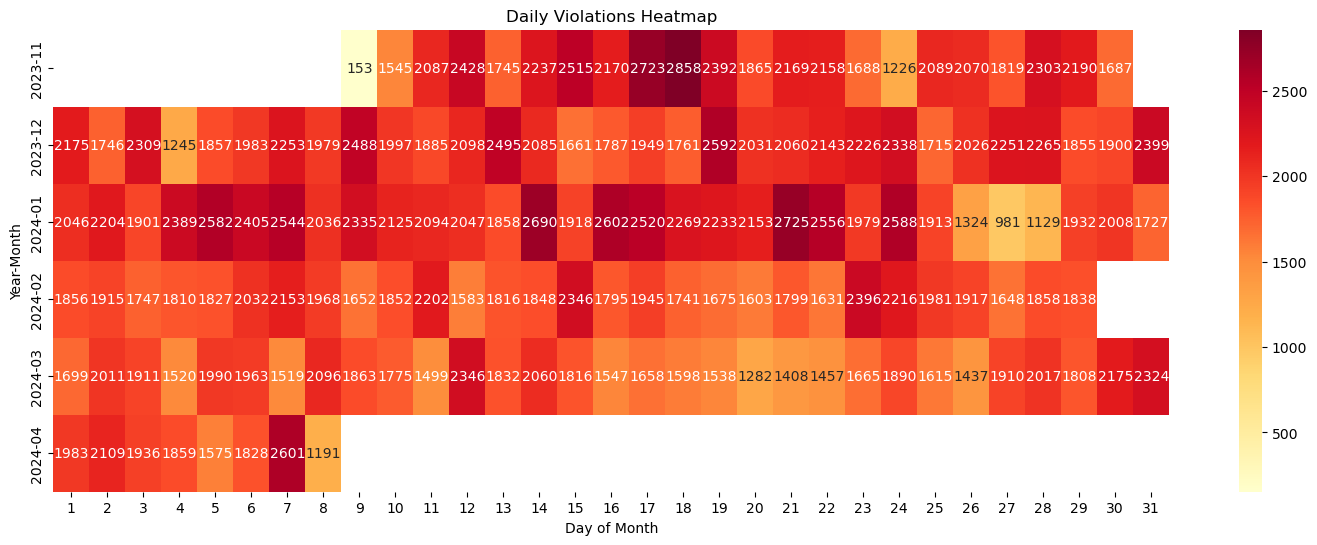

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count violations per day
daily_counts = df.groupby('date').size().reset_index(name='violations')

daily_counts['year_month'] = daily_counts['date'].dt.strftime('%Y-%m')
daily_counts['day'] = daily_counts['date'].dt.day

heatmap_data = daily_counts.pivot(
    index='year_month',
    columns='day',
    values='violations'
)

plt.figure(figsize=(18,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Daily Violations Heatmap')
plt.xlabel('Day of Month')
plt.ylabel('Year-Month')
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Count violations for each day-hour combination
hourly_counts = (
    df.groupby(['created_date', 'created_hour'])
      .size()
      .reset_index(name='violations')
)

# Mean violations for each hour across all days
mean_hourly = (
    hourly_counts.groupby('created_hour')['violations']
    .mean()
)

# Plot
plt.figure(figsize=(12, 5))
mean_hourly.plot(kind='line', marker='o')

plt.title('Mean Violations per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Violations')
plt.xticks(range(24))
plt.grid(True)
plt.show()

# Print values
print(mean_hourly)


KeyError: 'created_date'

In [8]:
print(df.columns.tolist())

['id', 'latitude', 'longitude', 'area', 'pincode', 'vehicle_type_encoded', 'PARKING NEAR ROAD CROSSING--104', 'PARKING ON FOOTPATH--105', 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS--106', 'PARKING IN A MAIN ROAD--107', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE--108', 'DOUBLE PARKING--109', 'FAIL TO USE SAFETY BELTS--110', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC--111', 'WRONG PARKING--112', 'NO PARKING--113', 'JUMPING TRAFFIC SIGNAL--115', 'DEFECTIVE NUMBER PLATE--116', 'CARRYING LENGHTY MATERIAL--123', 'REFUSE TO GO FOR HIRE--124', 'DEMANDING EXCESS FARE--125', 'VIOLATING LANE DISIPLINE--130', 'USING BLACK FILM/OTHER MATERIALS--133', 'U TURN PROHIBITED--134', 'AGAINST ONE WAY/NO ENTRY--135', 'OBSTRUCTING DRIVER--136', 'PARKING OTHER THAN BUS STOP--139', 'RIDER NOT WEARING HELMET--140', 'WITHOUT SIDE MIRROR--144', 'STOPING ON WHITE/STOP LINE--146', 'H T V PROHIBITED--147', '2W/3W - USING MOBILE PHONE--237', 'OTHER - USING MOBILE PHONE--437', 'created_year', 'created_month', 'created_

created_hour
0     144.105960
1     113.609272
2     164.039735
3     170.245033
4     192.728477
5     225.728477
6     178.079470
7      96.741722
8      56.662252
9      20.966667
10      4.980769
11      5.712871
12      4.055556
13      2.947368
14      1.777778
15      3.882353
16      7.849057
17     11.521127
18     15.279070
19     70.947020
20     78.370861
21    130.880795
22    151.251656
23    151.397351
Name: violations, dtype: float64


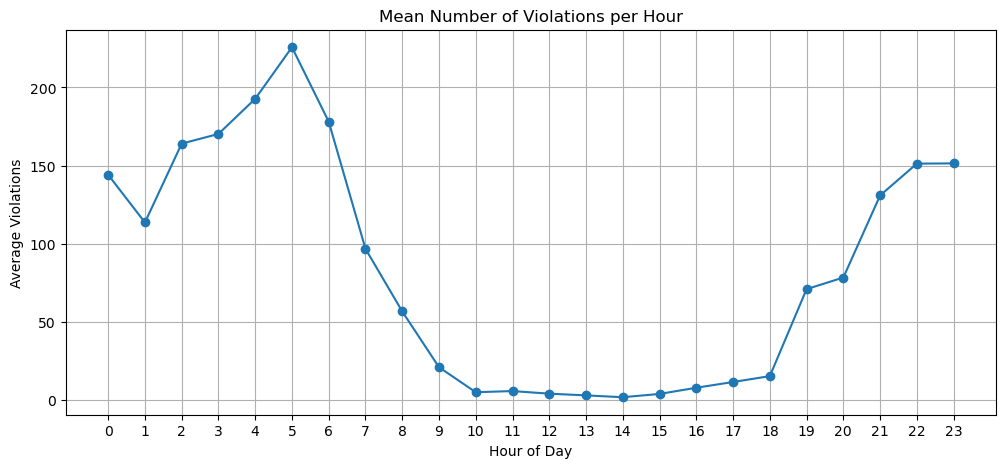

In [9]:
import matplotlib.pyplot as plt

# Count violations for each date-hour combination
hourly_counts = (
    df.groupby(['date', 'created_hour'])
      .size()
      .reset_index(name='violations')
)

# Mean violations for each hour across all days
mean_hourly = (
    hourly_counts.groupby('created_hour')['violations']
    .mean()
    .reindex(range(24), fill_value=0)
)

print(mean_hourly)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(mean_hourly.index,
         mean_hourly.values,
         marker='o')

plt.title('Mean Number of Violations per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Violations')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [10]:
# Count violations on each date
daily_counts = df.groupby('date').size()

# Mean violations per day
mean_violations_per_day = daily_counts.mean()

print("Mean :", daily_counts.mean())
print("Median :", daily_counts.median())
print("Min :", daily_counts.min())
print("Max :", daily_counts.max())
print("Std Dev :", daily_counts.std())

Mean : 1963.453947368421
Median : 1956.0
Min : 153
Max : 2858
Std Dev : 377.93741096487344


In [3]:
#!/usr/bin/env python3
"""
Feature Engineering Pipeline — Traffic Violation Data
======================================================
Steps
  1. PCU weight        → how much road space the vehicle occupies (IRC standard)
  2. Violation weight  → how badly each violation type disrupts traffic
  3. Road weight       → 1 / lane_count  (from OpenStreetMap)
  4. severity_score    = pcu_weight × road_weight × violation_type_weight
  5. location_key      → named junction, or GPS grid cell (~100 m) for 'No Junction'
  6. hour_slot         → floor datetime to hour
  7. Aggregate         → one row per location × hour  (time-series ready for Part 1)

Drop all operational/admin columns:
  modified_*, data_sent_to_scita*, device_id_int, created_by_id_int,
  center_code, updated_vehicle_type_encoded, validation_*,
  created_minute, created_second  (sub-hour granularity not used)
"""

import os, sys, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  — edit paths here if needed
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV  = 'data/processed_dataset_cleaned.csv'   # ← replace with your full CSV
OUTPUT_CSV = 'data/feature_engineered.csv'
GRID_PRECISION = 3    # decimal places for GPS grid (~100 m per unit)
OSM_PADDING    = 0.02 # degrees to pad bounding box when downloading OSM data
DEFAULT_LANES  = 2    # fallback if OSM has no lane data for a road segment

# ─────────────────────────────────────────────────────────────────────────────
# 0. Load
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 0 — Loading data")
df = pd.read_csv(INPUT_CSV)
print(f"  Rows: {len(df):,}   Columns: {len(df.columns)}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. PCU (Passenger Car Unit) weight — IRC standard
#    Measures how much road space each vehicle type consumes relative to a car.
#    Source: IRC SP:41 and traffic engineering literature for Indian conditions.
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 1 — PCU weights (vehicle type → road space)")

PCU_MAP = {
    0:  3.0,   # BUS (BMTC/KSRTC)        — large city bus
    1:  1.0,   # CAR                       — baseline (1.0 by definition)
    2:  3.0,   # FACTORY BUS               — same footprint as city bus
    3:  0.5,   # GOODS AUTO                — small 3-wheeler cargo
    4:  4.5,   # HGV (Heavy Goods Vehicle) — articulated/multi-axle truck
    5:  1.0,   # JEEP                      — car-equivalent
    6:  1.5,   # LGV (Light Goods Vehicle) — small truck / pickup
    7:  3.5,   # LORRY / GOODS VEHICLE     — standard 6-wheel truck
    8:  2.0,   # MAXI-CAB                  — large taxi/van
    9:  2.5,   # MINI LORRY               — medium truck
    10: 0.5,   # MOPED
    11: 0.5,   # MOTOR CYCLE
    12: 1.0,   # OTHERS                    — default to car
    13: 0.5,   # PASSENGER AUTO (rickshaw)
    14: 3.0,   # PRIVATE BUS
    15: 2.5,   # SCHOOL VEHICLE
    16: 0.5,   # SCOOTER
    17: 4.5,   # TANKER                    — same as HGV
    18: 1.5,   # TEMPO                     — light commercial van
    19: 3.0,   # TOURIST BUS
    20: 2.5,   # TRACTOR                   — slow-moving, wide
    21: 1.5,   # VAN                       — medium delivery van
}

df['pcu_weight'] = df['vehicle_type_encoded'].map(PCU_MAP).fillna(1.0)
print(f"  Distribution:\n{df['pcu_weight'].value_counts().sort_index().to_string()}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Violation-type weight
#    Reflects how severely each violation type disrupts traffic flow.
#    Scale: 0.3 (admin/personal safety, near-zero traffic impact)
#           1.0 (standard parking — blocks some space)
#           2.0 (signal jumping, wrong-way — highest accident + flow risk)
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 2 — Violation-type weights")

VIOLATION_WEIGHTS = {
    # ── Parking violations ────────────────────────────────────────────────────
    'PARKING NEAR ROAD CROSSING--104':                1.5,  # near junction, blocks sightlines
    'PARKING ON FOOTPATH--105':                       1.0,  # forces peds onto carriageway
    'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS--106': 1.8,  # obstructs signal compliance
    'PARKING IN A MAIN ROAD--107':                    1.5,  # reduces through-lane capacity
    'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE--108':1.3,  # creates pinch-point
    'DOUBLE PARKING--109':                            1.5,  # completely blocks a lane
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC--111':   1.5,  # high-footfall hazard zone
    'WRONG PARKING--112':                             1.0,  # generic parking offence
    'NO PARKING--113':                                1.0,  # generic no-parking zone
    'PARKING OTHER THAN BUS STOP--139':               1.0,  # blocks bus bay
    # ── Moving violations (high flow disruption) ──────────────────────────────
    'JUMPING TRAFFIC SIGNAL--115':                    2.0,  # collision risk, clears intersection badly
    'AGAINST ONE WAY/NO ENTRY--135':                  2.0,  # head-on risk
    'VIOLATING LANE DISIPLINE--130':                  1.5,  # weaving → ripple congestion
    'U TURN PROHIBITED--134':                         1.5,  # cuts across oncoming traffic
    'OBSTRUCTING DRIVER--136':                        1.8,  # directly causes near-misses
    'STOPING ON WHITE/STOP LINE--146':                1.3,  # blocks pedestrian crossing
    'H T V PROHIBITED--147':                          1.5,  # heavy vehicle on restricted road
    'CARRYING LENGHTY MATERIAL--123':                 1.5,  # overhangs into adjacent lanes
    # ── Distracted driving ────────────────────────────────────────────────────
    '2W/3W - USING MOBILE PHONE--237':                1.5,
    'OTHER - USING MOBILE PHONE--437':                1.5,
    # ── Personal safety / admin (low traffic-flow impact) ─────────────────────
    'FAIL TO USE SAFETY BELTS--110':                  0.5,  # personal risk only
    'RIDER NOT WEARING HELMET--140':                  0.5,  # personal risk only
    'WITHOUT SIDE MIRROR--144':                       0.5,  # minor safety issue
    'DEFECTIVE NUMBER PLATE--116':                    0.5,  # admin / identification
    'USING BLACK FILM/OTHER MATERIALS--133':          0.5,  # visibility offence
    'REFUSE TO GO FOR HIRE--124':                     0.3,  # commercial dispute, no flow impact
    'DEMANDING EXCESS FARE--125':                     0.3,  # commercial dispute, no flow impact
}

viol_cols = [c for c in VIOLATION_WEIGHTS if c in df.columns]
missing   = [c for c in VIOLATION_WEIGHTS if c not in df.columns]
if missing:
    print(f"  ⚠ {len(missing)} violation columns not found in data (skipped): {missing}")

# Each row can have multiple violations flagged (binary columns).
# Sum up weighted flags to get combined violation severity for that record.
viol_score = pd.Series(0.0, index=df.index)
for col in viol_cols:
    viol_score += df[col].fillna(0) * VIOLATION_WEIGHTS[col]

# Edge-case: if no violation column is flagged (shouldn't happen in clean data),
# default to 1.0 so the record isn't silently zeroed out.
df['violation_type_weight'] = viol_score.where(viol_score > 0, 1.0)
print(f"  violation_type_weight range: "
      f"{df['violation_type_weight'].min():.2f} – {df['violation_type_weight'].max():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Lane count from OpenStreetMap → road_weight = 1 / lanes
#    Logic: a blocked lane on a 1-lane road removes 100% of capacity;
#           on a 4-lane road it removes only 25% → weight scales inversely.
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 3 — Lane count from OpenStreetMap")

import osmnx as ox
from scipy.spatial import cKDTree

# Bounding box with padding so edge roads aren't missed
lat_min = df['latitude'].min()  - OSM_PADDING
lat_max = df['latitude'].max()  + OSM_PADDING
lon_min = df['longitude'].min() - OSM_PADDING
lon_max = df['longitude'].max() + OSM_PADDING

print(f"  bbox: lat [{lat_min:.4f}, {lat_max:.4f}]  "
      f"lon [{lon_min:.4f}, {lon_max:.4f}]")
print("  Querying Overpass API (may take 30–120 s for large city areas)…")

osm_success = False
try:
    # osmnx 2.x: bbox = (left, bottom, right, top) = (W, S, E, N)
    G = ox.graph_from_bbox(
        bbox=(lon_min, lat_min, lon_max, lat_max),
        network_type='drive'
    )
    edges_gdf = ox.graph_to_gdfs(G, nodes=False).reset_index()
    print(f"  OSM road segments: {len(edges_gdf):,}")

    def parse_lanes(raw):
        """OSM 'lanes' can be NaN, an int string, a ';'-separated list,
        or a Python list (if multiple values on the same edge)."""
        if raw is None:
            return np.nan
        if isinstance(raw, list):
            raw = raw[0]
        if pd.isna(raw):
            return np.nan
        try:
            return float(str(raw).split(';')[0].strip())
        except ValueError:
            return np.nan

    lane_col = edges_gdf['lanes'] if 'lanes' in edges_gdf.columns \
               else pd.Series([np.nan] * len(edges_gdf))
    edges_gdf['lane_count'] = lane_col.apply(parse_lanes)

    osm_coverage = edges_gdf['lane_count'].notna().mean() * 100
    print(f"  OSM lane coverage: {osm_coverage:.1f}% of segments have lane data")
    edges_gdf['lane_count'] = edges_gdf['lane_count'].fillna(DEFAULT_LANES)

    # Build a KD-tree from edge midpoints (lat, lon) for fast nearest-road lookup.
    # Using midpoints of each segment is accurate enough for ~100 m GPS precision.
    edge_lats, edge_lons, lane_vals = [], [], []
    for _, row in edges_gdf.iterrows():
        try:
            coords = list(row['geometry'].coords)
            mid    = coords[len(coords) // 2]   # midpoint of segment
            edge_lons.append(mid[0])
            edge_lats.append(mid[1])
            lane_vals.append(row['lane_count'])
        except Exception:
            continue

    tree     = cKDTree(np.column_stack([edge_lats, edge_lons]))
    _, idxs  = tree.query(df[['latitude', 'longitude']].values, k=1)
    df['lane_count'] = np.array(lane_vals)[idxs]

    pct_non_default = (df['lane_count'] != DEFAULT_LANES).mean() * 100
    print(f"  Violations matched to non-default lane count: {pct_non_default:.1f}%")
    osm_success = True

except Exception as exc:
    print(f"  ⚠ OSM query failed: {exc}")
    print(f"  → Falling back to default {DEFAULT_LANES} lanes for all rows")
    df['lane_count'] = float(DEFAULT_LANES)

df['road_weight'] = 1.0 / df['lane_count']
print(f"  road_weight range: {df['road_weight'].min():.3f} – {df['road_weight'].max():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Severity score  =  pcu_weight × road_weight × violation_type_weight
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 4 — Severity score")
df['severity_score'] = (
    df['pcu_weight'] * df['road_weight'] * df['violation_type_weight']
)
print(f"  severity_score stats:\n{df['severity_score'].describe().round(3).to_string()}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Location key
#    Named junction (cleaned) when available; GPS grid cell otherwise.
#    3 decimal places ≈ 111 m × cos(lat) ≈ 100 m in Bangalore (lat ~13°).
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 5 — Location key")

NO_JN = {'no junction', 'nan', '', 'none'}

def make_location_key(row):
    jn = str(row.get('junction_name', '')).strip()
    if jn.lower() not in NO_JN:
        return jn                          # real named junction
    lat_g = round(row['latitude'],  GRID_PRECISION)
    lon_g = round(row['longitude'], GRID_PRECISION)
    return f"grid_{lat_g}_{lon_g}"        # ~100 m grid cell

df['location_key'] = df.apply(make_location_key, axis=1)

n_named = df['location_key'].str.startswith('grid_').eq(False).sum()
n_grid  = df['location_key'].str.startswith('grid_').sum()
print(f"  Named junctions:  {n_named:,} rows  "
      f"({df[~df['location_key'].str.startswith('grid_')]['location_key'].nunique()} unique)")
print(f"  GPS grid cells:   {n_grid:,} rows  "
      f"({df[df['location_key'].str.startswith('grid_')]['location_key'].nunique()} unique)")

# ─────────────────────────────────────────────────────────────────────────────
# 6. Datetime → hour_slot
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 6 — Datetime / hour slot")

# created_* columns are stored as floats (e.g. 2023.0); coerce to int safely
for col in ['created_year', 'created_month', 'created_day', 'created_hour']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['datetime']  = pd.to_datetime(
    dict(year=df['created_year'], month=df['created_month'],
         day=df['created_day'],   hour=df['created_hour'],
         minute=0, second=0),
    errors='coerce'
)
bad_dates = df['datetime'].isna().sum()
if bad_dates:
    print(f"  ⚠ {bad_dates} rows have unparseable dates — will be excluded from aggregation")

df['hour_slot'] = df['datetime'].dt.floor('h')
print(f"  Date range: {df['hour_slot'].min()} → {df['hour_slot'].max()}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. Aggregate: one row per location × hour
#    This is the time-series format needed by Part 1 lookback features.
# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 7 — Aggregating to location × hour")

agg_spec = {
    # ── Core severity metrics ─────────────────────────────────────────────────
    'severity_score':        'sum',   # total severity in this location-hour
    'pcu_weight':            'sum',   # total PCU load (proxy for vehicle-hours lost)
    'violation_type_weight': 'mean',  # avg severity of violations in this slot
    'lane_count':            'mean',  # representative lane count for location
    # ── Counts ───────────────────────────────────────────────────────────────
    'id':                    'count', # renamed to violation_count below
    # ── Spatial ──────────────────────────────────────────────────────────────
    'latitude':              'mean',
    'longitude':             'mean',
    'area':                  'first',
    'pincode':               'first',
    'police_station':        'first',
}
# Sum each violation-type column so Part 1 can inspect which type dominated
for col in viol_cols:
    agg_spec[col] = 'sum'

out = (
    df.dropna(subset=['hour_slot'])
      .groupby(['location_key', 'hour_slot'], sort=True)
      .agg(agg_spec)
      .reset_index()
)
out.rename(columns={'id': 'violation_count'}, inplace=True)

# ── Temporal features for lookback feature construction (Part 1) ───────────
out['year']       = out['hour_slot'].dt.year
out['month']      = out['hour_slot'].dt.month
out['day']        = out['hour_slot'].dt.day
out['hour']       = out['hour_slot'].dt.hour
out['weekday']    = out['hour_slot'].dt.weekday  # 0 = Monday … 6 = Sunday
out['is_weekend'] = (out['weekday'] >= 5).astype(int)

# Add road_weight (derived from aggregated lane_count, kept explicit for clarity)
out['road_weight'] = 1.0 / out['lane_count']

# ── Reorder columns logically ─────────────────────────────────────────────────
id_cols   = ['location_key', 'hour_slot',
             'year', 'month', 'day', 'hour', 'weekday', 'is_weekend']
spatial   = ['latitude', 'longitude', 'area', 'pincode', 'police_station']
severity  = ['violation_count', 'severity_score',
             'pcu_weight', 'violation_type_weight',
             'lane_count', 'road_weight']
viol_detail = viol_cols

final_cols = id_cols + spatial + severity + viol_detail
out = out[[c for c in final_cols if c in out.columns]]

print(f"  Output shape: {out.shape}")
print(f"  Unique locations: {out['location_key'].nunique()}")
print(f"  Unique hours:     {out['hour_slot'].nunique()}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. Save
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
out.to_csv(OUTPUT_CSV, index=False)
print(f"\n{'='*60}")
print(f"✓  Saved → {OUTPUT_CSV}")
print(f"   Rows: {len(out):,}   Columns: {len(out.columns)}")
print(f"\nColumn list:")
for i, col in enumerate(out.columns, 1):
    print(f"  {i:2d}. {col}")

# ── Summary: dropped columns (for audit) ─────────────────────────────────────
kept_from_raw = {'id','latitude','longitude','area','pincode','vehicle_type_encoded',
                 'police_station','junction_name'} | set(viol_cols)
all_raw = set(df.columns)
dropped = sorted(all_raw - kept_from_raw - {
    'pcu_weight','violation_type_weight','road_weight','lane_count',
    'severity_score','location_key','datetime','hour_slot'
})
print(f"\nDropped operational/admin columns ({len(dropped)}):")
for c in dropped:
    print(f"  - {c}")

STEP 0 — Loading data
  Rows: 298,450   Columns: 65

STEP 1 — PCU weights (vehicle type → road space)
  Distribution:
pcu_weight
0.5    178613
1.0     90678
1.5     11089
2.0     11372
2.5       641
3.0      3531
3.5      1122
4.5      1404

STEP 2 — Violation-type weights
  violation_type_weight range: 1.00 – 13.20

STEP 3 — Lane count from OpenStreetMap
  bbox: lat [12.7827, 13.3137]  lon [77.4226, 77.7917]
  Querying Overpass API (may take 30–120 s for large city areas)…
  OSM road segments: 619,366
  OSM lane coverage: 5.3% of segments have lane data
  Violations matched to non-default lane count: 7.4%
  road_weight range: 0.167 – 1.000

STEP 4 — Severity score
  severity_score stats:
count    298450.000
mean          0.503
std           0.587
min           0.083
25%           0.250
50%           0.250
75%           0.500
max          24.975

STEP 5 — Location key
  Named junctions:  110,482 rows  (132 unique)
  GPS grid cells:   187,968 rows  (6203 unique)

STEP 6 — Datetime / hou

In [2]:
import sys
!{sys.executable} -m pip install osmnx

  Using cached osmnx-2.1.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl.metadata (31 kB)
Using cached osmnx-2.1.0-py3-none-any.whl (104 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl (22.9 MB)
Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl (6.3 MB)
Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------